In [1]:
# imports

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import random_split
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR

from torch.utils.data import TensorDataset, DataLoader
import fitsio
import matplotlib.pyplot as plt

In [3]:
def save_model_checkpoint(
    filepath: str,
    model: torch.nn.Module,
    optimizer: torch.optim.Optimizer = None,
    scheduler = None,
    epoch: int = 0,
    val_loss: float = float("inf"),
    config: dict = None
):
    """
    Saves a comprehensive PyTorch model checkpoint.
    """
    checkpoint = {
        "epoch": epoch,
        "val_loss": val_loss,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer else None,
        "scheduler_state_dict": scheduler.state_dict() if scheduler else None,
        "config": config or {}
    }
    torch.save(checkpoint, filepath)
    print(f"--> Saved checkpoint to '{filepath}' (Epoch {epoch+1}, Val Loss: {val_loss:.4f})")


def load_model_checkpoint(
    filepath: str,
    device: torch.device,
    model_class=None,
):
    """
    Loads a saved checkpoint and returns the model, optimizer/scheduler states, and metadata.
    """
    checkpoint = torch.load(filepath, map_location=device)
    config = checkpoint["config"]

    # Reconstruct model architecture using stored configuration
    model = model_class(
        in_channels=config.get("in_channels", 2),
        num_species=config.get("num_species", 1)
    ).to(device)

    # Load weights
    model.load_state_dict(checkpoint["model_state_dict"])
    
    print(f"--> Loaded checkpoint '{filepath}' (Trained for {checkpoint['epoch']+1} epochs, Val Loss: {checkpoint['val_loss']:.4f})")
    return model, checkpoint

In [ ]:
#list of all metals 

# metal_list = [
#     "MgI(2853)", "MgII(2804)", "MgII(2796)",
#     "FeII(2600)", "FeII(2587)", "MnII(2577)",
#     "FeII(2383)", "FeII(2374)", "FeII(2344)",
#     "AlIII(1863)", "AlIII(1855)", "AlII(1671)",
#     "FeII(1608)", "CIV(1551)", "CIV(1548)",
#     "SiII(1527)", "SiIV(1403)", "SiIV(1394)",
#     "CII(1335)", "SiII(1304)", "OI(1302)",
#     "SiII(1260)", "NV(1243)", "NV(1239)",
#     "SiIII(1207)", "NI(1200)", "SiII(1193)", "SiII(1190)",
#     "OI(1039)", "OVI(1038)", "OVI(1032)",
#     "LYB", "CIII(977)", "OI(989)", "SiII(990)",
#     "LY3", "LY4", "LY5",
# ]
# strength_list = [
#     "1e-4", "5e-4", "9e-4",          # MgI MgII(2804) MgII(2796)
#     "1e-4", "1e-4", "1e-4",          # FeII(2600) FeII(2587) MnII(2577)
#     "1e-4", "1e-4", "1e-4",          # FeII(2383) FeII(2374) FeII(2344)
#     "1e-4", "1e-4", "1e-4",          # AlIII(1863) AlIII(1855) AlII(1671)
#     "1e-4", "5.435e-4", "1.487e-3",  # FeII(1608) CIV(1551) CIV(1548)
#     "1e-4", "5e-4", "9e-4",          # SiII(1527) SiIV(1403) SiIV(1394)
#     "1e-4", "1e-4", "1e-4",          # CII(1335) SiII(1304) OI(1302)
#     "4.2504e-4", "5e-4", "5e-4",     # SiII(1260)* NV(1243) NV(1239)
#     "9.4595e-4", "1e-3", "6.354e-4", "4.496e-4",  # SiIII(1207)* NI(1200) SiII(1193)* SiII(1190)*
#     "1e-3", "3.382e-3", "5.358e-3",  # OI(1039) OVI(1038) OVI(1032)
#     "0.1901", "5e-3", "1e-3", "1e-3",# LYB CIII(977) OI(989) SiII(990)
#     "0.0697", "0.0335", "0.0187",    # LY3 LY4 LY5
# ]


# # Expected format: 
# METAL_LINES_LIST = {
#     "SiII_1190": 1190.4158,
#     "SiII_1193": 1193.2897,
#     "SiIII_1207": 1206.500,
#     "SiII_1260": 1206.500,
#     "CIV_1548": 1548.2049,
#     "CIV_1550": 1550.77845,
#     'MgI(2853)': 2852.96,
# }

### Check transmission file from P1D code

Wavelength shape: (31001,)
Single flux shape: (31001,)


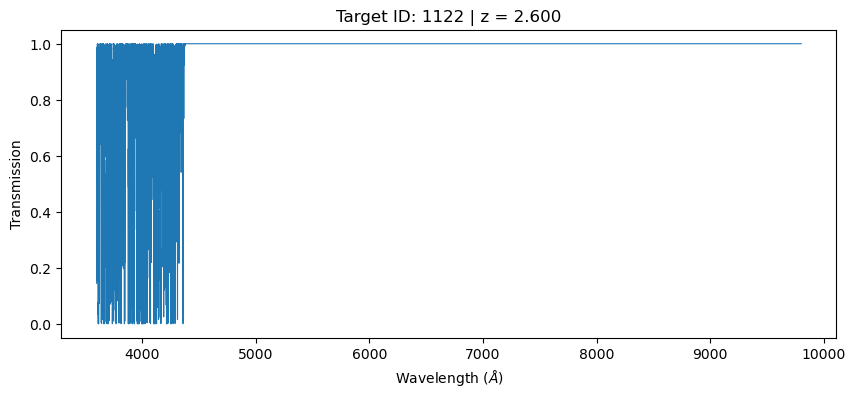

In [4]:
# load transmission file (preprocessed)
p1d_file = '/global/cfs/cdirs/desicollab/users/mherbold/p1d_mocks/DR1/QQ_output_test/transmission-16-1_2.fits'

# Read arrays
meta = fitsio.read(p1d_file, ext="METADATA")
wave = fitsio.read(p1d_file, ext="WAVELENGTH")
fluxes = fitsio.read(p1d_file, ext="TRANSMISSION")

# Pick single spectrum index
i = 100

# Extract and squeeze shape
single_flux = fluxes[i].squeeze()
target_id = meta["MOCKID"][i]
z = meta["Z"][i]

# Check shapes directly
print(f"Wavelength shape: {wave.shape}")        # Output: (31001,)
print(f"Single flux shape: {single_flux.shape}")  # Output: (31001,)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(wave, single_flux, lw=0.8)
plt.xlabel(r"Wavelength ($\AA$)")
plt.ylabel("Transmission")
plt.title(f"Target ID: {target_id} | z = {z:.3f}")
# plt.xlim(3000,5000)
plt.show()

### Generate training samples

In [5]:
def rebin_dataset_to_log_lambda(wave_grid: np.ndarray, fluxes: np.ndarray, num_log_pixels: int = None):
    """
    Interpolates a batch of flux spectra from a linear wavelength grid 
    to a strictly uniform log-wavelength grid (constant delta ln(wave)).
    """
    # Define uniform log-wavelength bounds
    log_wave_min = np.log(wave_grid[0])
    log_wave_max = np.log(wave_grid[-1])
    
    if num_log_pixels is None:
        num_log_pixels = len(wave_grid)
        
    log_wave_grid = np.linspace(log_wave_min, log_wave_max, num_log_pixels)
    linear_wave_from_log = np.exp(log_wave_grid)
    
    # Re-interpolate all spectra onto the new uniform log wavelength grid
    N_specs = fluxes.shape[0]
    fluxes_log = np.zeros((N_specs, num_log_pixels), dtype=np.float32)
    
    for idx in range(N_specs):
        fluxes_log[idx] = np.interp(linear_wave_from_log, wave_grid, fluxes[idx])
        
    return log_wave_grid, fluxes_log

In [6]:
def generate_multimetal_dataset(
    lya_flux_samples: np.ndarray,
    log_wave_grid: np.ndarray,
    metal_dict: dict,
    lya_wave: float = 1215.67,
    num_samples: int = 5000,           # Increased sample count
    max_metals_per_spectrum: int = 1,
    snr: float = 30.0,
    tau_min_thresh: float = 0.05,
    zero_metal_prob: float = 0.25,      # 25% pure LyA forest spectra (no metals)
    a_min: float = 0.2,
    a_max: float = 1.0,
) -> TensorDataset:
    
    n_input, n_pixels = lya_flux_samples.shape
    num_species = len(metal_dict)
    species_keys = list(metal_dict.keys())
    d_log_wave = log_wave_grid[1] - log_wave_grid[0]
    
    pixel_shifts = {
        key: int(np.round(np.log(w / lya_wave) / d_log_wave))
        for key, w in metal_dict.items()
    }

    X_data = np.zeros((num_samples, 1 + num_species, n_pixels), dtype=np.float32)
    Y_mask = np.zeros((num_samples, num_species, n_pixels), dtype=np.float32)
    Y_amp  = np.zeros((num_samples, num_species, n_pixels), dtype=np.float32)

    tau_lya_pool = -np.log(np.clip(lya_flux_samples, 1e-4, 1.0))

    for i in range(num_samples):
        rand_idx = np.random.randint(0, n_input)
        tau_lya = tau_lya_pool[rand_idx]
        tau_total = np.copy(tau_lya)
        
        # Decide whether to inject metals into this sample
        inject_metal = (np.random.rand() > zero_metal_prob)

        if inject_metal:
            n_active = np.random.randint(1, max_metals_per_spectrum + 1)
            active_species = np.random.choice(species_keys, size=n_active, replace=False)

            for species in active_species:
                s_idx = species_keys.index(species)
                shift = pixel_shifts[species]
                
                A = np.random.uniform(a_min, a_max)
                log10_A = np.log10(A)
                
                tau_metal = np.roll(tau_lya, shift)
                if shift > 0:
                    tau_metal[:shift] = 0.0
                elif shift < 0:
                    tau_metal[shift:] = 0.0
                    
                tau_metal_effective = A * tau_metal
                tau_total += tau_metal_effective
                
                metal_active_mask = (tau_metal_effective >= tau_min_thresh)
                Y_mask[i, s_idx, :] = metal_active_mask.astype(np.float32)
                Y_amp[i, s_idx, :]  = log10_A

        # Flux conversion & noise injection
        flux_true = np.exp(-tau_total)
        if snr is None or snr >= 1e5:
            flux_obs = flux_true
        else:
            noise = np.random.normal(0.0, 1.0 / snr, size=n_pixels)
            flux_obs = np.clip(flux_true + noise, 1e-4, 1.5)
            
        tau_obs = -np.log(np.clip(flux_obs, 1e-4, 1.0))

        X_data[i, 0, :] = tau_obs
        for s_idx, species in enumerate(species_keys):
            shift = pixel_shifts[species]
            X_data[i, 1 + s_idx, :] = np.roll(tau_obs, shift)

    return TensorDataset(
        torch.from_numpy(X_data),
        torch.from_numpy(Y_mask),
        torch.from_numpy(Y_amp)
    )

In [7]:
# 1. Resample wavelength AND fluxes to uniform log space
log_wave, fluxes_log = rebin_dataset_to_log_lambda(wave, fluxes)

# 2. Build multi-metal dataset
dataset = generate_multimetal_dataset(
    lya_flux_samples=fluxes_log,
    log_wave_grid=log_wave,
    # metal_dict={"SiII_1260": 1260.42, 'MgI_2853': 2852.96, "CIV_1550": 1550.77845},
    metal_dict={"SiII_1260": 1260.42},
    num_samples=5000,
    max_metals_per_spectrum=1,
    tau_min_thresh = 0.05,
    zero_metal_prob = 0.25, # 25% pure LyA forest spectra (no metals)
    snr=None,
    a_min = 0.01, 
    a_max = 0.01,    
    )

# 3. Create DataLoader (Yields: X, y_mask, y_amp)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Test shape of single batch
for X_batch, y_mask_batch, y_amp_batch in train_loader:
    print(f"X batch shape:      {X_batch.shape}")      # (32, 2, 31001)
    print(f"Mask batch shape:   {y_mask_batch.shape}") # (32, 1, 31001)
    print(f"Amp batch shape:    {y_amp_batch.shape}")  # (32, 1, 31001)
    break

X batch shape:      torch.Size([32, 2, 31001])
Mask batch shape:   torch.Size([32, 1, 31001])
Amp batch shape:    torch.Size([32, 1, 31001])


In [8]:
def plot_example_training_samples(
    dataset, 
    metal_dict: dict, 
    log_wave_grid: np.ndarray = None, 
    num_samples: int = 3,
    zoom_margin_pixels: int = 250,
):
    """
    Plots example samples from the multi-metal dataset for visual inspection.
    Converts tau_obs back to normalized flux (F = exp(-tau)) and overlays ground truth masks.
    """
    species_names = list(metal_dict.keys())
    num_species = len(species_names)
    
    # Palette for highlighting active metal masks
    palette = plt.cm.get_cmap("Set1", max(8, num_species))
    
    # Randomly pick sample indices
    indices = np.random.choice(len(dataset), size=num_samples, replace=False)
    
    # Establish X-axis (Wavelength vs. Pixel Index)
    if log_wave_grid is not None:
        # Auto-detect if log_wave_grid is natural log, log10, or already lambda
        if np.max(log_wave_grid) > 100:
            wave_axis = log_wave_grid
        elif np.max(log_wave_grid) < 5:  # log10 space (~3.1 to 3.5 for optical/UV)
            wave_axis = 10.0 ** log_wave_grid
        else:  # natural log space (~7.1 to 8.1)
            wave_axis = np.exp(log_wave_grid)
        x_label = r"Wavelength ($\AA$)"
    else:
        wave_axis = np.arange(dataset[0][0].shape[-1])
        x_label = "Pixel Index"

    fig, axes = plt.subplots(num_samples, 1, figsize=(14, 3.5 * num_samples), sharex=False)
    if num_samples == 1:
        axes = [axes]

    for i, idx in enumerate(indices):
        ax = axes[i]
        
        # Unpack tensors
        X, Y_mask, Y_amp = dataset[idx]
        tau_obs = X[0].numpy()
        flux_obs = np.exp(-tau_obs)  # Convert optical depth to flux space
        masks = Y_mask.numpy()
        amps = Y_amp.numpy()
        
        # Plot normalized flux
        ax.plot(wave_axis, flux_obs, color="black", lw=0.7, alpha=0.8, label=r"Observed Flux ($e^{-\tau}$)")
        ax.axhline(1.0, color="gray", linestyle="--", lw=1, alpha=0.5)
        
        # Overlay injected species masks
        injected_info = []
        active_pixel_indices = []

        for s_idx, s_name in enumerate(species_names):
            mask_s = masks[s_idx] > 0.5
            if np.any(mask_s):
                color = palette(s_idx)
                
                # Get linear amplitude A = 10^(log10_A)
                amp_val = 10.0 ** np.median(amps[s_idx, mask_s])
                injected_info.append(f"{s_name} (A={amp_val:.2f})")
                
                # Store active indices to handle optional zoom cropping
                active_pixel_indices.extend(np.where(mask_s)[0])
                
                # Fill region under active line mask
                ax.fill_between(
                    wave_axis, 
                    0, 
                    1.2, 
                    where=mask_s, 
                    color=color, 
                    alpha=0.35, 
                    label=f"Mask: {s_name}"
                )

        # Set title and labels
        title_str = f"Sample #{idx} | " + (f"Injected: {', '.join(injected_info)}" if injected_info else "Pure Lya Forest (No Metals)")
        ax.set_title(title_str, fontsize=11, fontweight="bold")
        ax.set_ylabel("Normalized Flux")
        ax.set_ylim(-0.05, 1.25)
        ax.grid(True, alpha=0.25)
        ax.legend(loc="lower left", fontsize=9, framealpha=0.9)
        ax.set_xlabel(x_label)

        # Zoom into active metal region if present
        if len(active_pixel_indices) > 0 and zoom_margin_pixels is not None:
            min_pix = max(0, np.min(active_pixel_indices) - zoom_margin_pixels)
            max_pix = min(len(wave_axis) - 1, np.max(active_pixel_indices) + zoom_margin_pixels)
            ax.set_xlim(wave_axis[min_pix], wave_axis[max_pix])

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_457226/2668633681.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  palette = plt.cm.get_cmap("Set1", max(8, num_species))


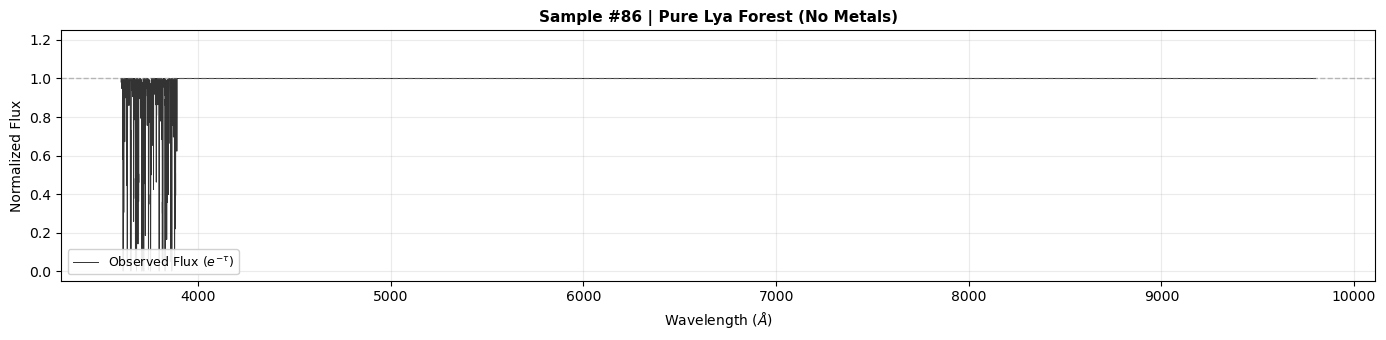

In [9]:
# plot example training data
plot_example_training_samples(
    dataset, 
    # metal_dict={"SiII_1260": 1260.42, 'MgI_2853': 2852.96, "CIV_1550": 1550.77845},
    metal_dict = {"SiII_1260": 1260.42},
    log_wave_grid = log_wave, 
    num_samples = 1,
    # zoom_margin_pixels: int = 250,
)

### Setting up the CNN Architecture

In [11]:
# class SpectralMetalCNN(nn.Module):
#     def __init__(self):
#         super().__init__()
#         # 1D Conv backbone to extract multi-scale cross-correlation features
#         self.features = nn.Sequential(
#             nn.Conv1d(in_channels=2, out_channels=32, kernel_size=7, stride=2, padding=3),
#             nn.BatchNorm1d(32),
#             nn.ReLU(),
#             nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
#             nn.BatchNorm1d(64),
#             nn.ReLU(),
#             nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2),
#             nn.BatchNorm1d(128),
#             nn.ReLU(),
#             nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1),
#             nn.BatchNorm1d(256),
#             nn.ReLU(),
#             nn.AdaptiveAvgPool1d(1)  # Pools variable pixel dimensions to shape (B, 256, 1)
#         )
#         # Regression head predicting log10(A)
#         self.regressor = nn.Sequential(
#             nn.Linear(256, 64),
#             nn.ReLU(),
#             nn.Linear(64, 1)
#         )

#     def forward(self, x: torch.Tensor) -> torch.Tensor:
#         feat = self.features(x)
#         feat = torch.flatten(feat, 1)
#         out = self.regressor(feat)
#         return out.squeeze(-1)  # Shape: (batch_size,)

In [12]:
class ConvBlock1D(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=5, padding=2),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
            nn.Conv1d(out_ch, out_ch, kernel_size=5, padding=2),
            nn.BatchNorm1d(out_ch),
            nn.ReLU()
        )
    def forward(self, x):
        return self.net(x)

class SpectralUNet1D(nn.Module):
    def __init__(self, in_channels: int, num_species: int):
        super().__init__()
        # Encoder
        self.enc1 = ConvBlock1D(in_channels, 32)
        self.pool1 = nn.MaxPool1d(2)
        self.enc2 = ConvBlock1D(32, 64)
        self.pool2 = nn.MaxPool1d(2)
        self.enc3 = ConvBlock1D(64, 128)
        self.pool3 = nn.MaxPool1d(2)
        
        # Bottleneck
        self.bottleneck = ConvBlock1D(128, 256)
        
        # Decoder
        self.dec3 = ConvBlock1D(256 + 128, 128)
        self.dec2 = ConvBlock1D(128 + 64, 64)
        self.dec1 = ConvBlock1D(64 + 32, 32)
        
        # Output Heads (1D convolutions with 1x1 kernel)
        self.cls_head = nn.Conv1d(32, num_species, kernel_size=1) # Logits
        self.reg_head = nn.Conv1d(32, num_species, kernel_size=1) # Amplitude log10(A)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        
        # Bottleneck
        b = self.bottleneck(self.pool3(e3))
        
        # Decoder with length-matched upsampling
        d3 = F.interpolate(b, size=e3.shape[-1], mode='linear', align_corners=False)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        
        d2 = F.interpolate(d3, size=e2.shape[-1], mode='linear', align_corners=False)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        
        d1 = F.interpolate(d2, size=e1.shape[-1], mode='linear', align_corners=False)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        
        # Heads
        mask_logits = self.cls_head(d1)
        amp_pred = self.reg_head(d1)
        
        return mask_logits, amp_pred

In [13]:
# class MultiMetalLoss(nn.Module):
#     def __init__(self, reg_weight: float = 1.0):
#         super().__init__()
#         self.bce = nn.BCEWithLogitsLoss()
#         self.smooth_l1 = nn.SmoothL1Loss(reduction='sum')
#         self.reg_weight = reg_weight

#     def forward(self, pred_logits, pred_amp, target_mask, target_amp):
#         # 1. Classification Loss across all pixels
#         loss_cls = self.bce(pred_logits, target_mask)
        
#         # 2. Masked Regression Loss (only computed on pixels where metals exist)
#         num_positives = target_mask.sum() + 1e-6
#         masked_amp_diff = (pred_amp - target_amp) * target_mask
#         loss_reg = self.smooth_l1(masked_amp_diff, torch.zeros_like(masked_amp_diff)) / num_positives
        
#         total_loss = loss_cls + self.reg_weight * loss_reg
#         return total_loss, loss_cls, loss_reg

# class WeightedMultiMetalLoss(nn.Module):
#     def __init__(self, pos_weight: float = 8.0, reg_weight: float = 1.0):
#         super().__init__()
#         # pos_weight compensates for the ~9:1 ratio of background vs metal pixels
#         self.register_buffer("pos_weight_tensor", torch.tensor([pos_weight]))
#         self.reg_weight = reg_weight
#         self.smooth_l1 = nn.SmoothL1Loss(reduction='sum')

#     def forward(self, pred_logits, pred_amp, target_mask, target_amp):
#         # 1. Class-weighted BCE Loss
#         bce_loss = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight_tensor.to(pred_logits.device))
#         loss_cls = bce_loss(pred_logits, target_mask)
        
#         # 2. Masked Regression Loss (evaluated only at valid target metal pixels)
#         num_positives = target_mask.sum() + 1e-6
#         masked_amp_diff = (pred_amp - target_amp) * target_mask
#         loss_reg = self.smooth_l1(masked_amp_diff, torch.zeros_like(masked_amp_diff)) / num_positives
        
#         total_loss = loss_cls + self.reg_weight * loss_reg
#         return total_loss, loss_cls, loss_reg

In [14]:
class CalibratedMultiMetalLoss(nn.Module):
    def __init__(self, pos_weight: float = 2.5, reg_weight: float = 1.0):
        super().__init__()
        self.register_buffer("pos_weight_tensor", torch.tensor([pos_weight]))
        self.reg_weight = reg_weight
        self.smooth_l1 = nn.SmoothL1Loss(reduction='sum')

    def forward(self, pred_logits, pred_amp, target_mask, target_amp):
        bce_loss = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight_tensor.to(pred_logits.device))
        loss_cls = bce_loss(pred_logits, target_mask)
        
        num_positives = target_mask.sum() + 1e-6
        masked_amp_diff = (pred_amp - target_amp) * target_mask
        loss_reg = self.smooth_l1(masked_amp_diff, torch.zeros_like(masked_amp_diff)) / num_positives
        
        total_loss = loss_cls + self.reg_weight * loss_reg
        return total_loss, loss_cls, loss_reg

In [15]:
class DilatedBlock1D(nn.Module):
    """
    Multi-scale 1D block using dilated convolutions to expand receptive field
    for cross-correlating line profiles across forest clutter.
    """
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size=3, padding=1, dilation=1)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size=3, padding=2, dilation=2)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.conv3 = nn.Conv1d(out_ch, out_ch, kernel_size=3, padding=4, dilation=4)
        self.bn3   = nn.BatchNorm1d(out_ch)
        
        self.shortcut = nn.Conv1d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        res = self.shortcut(x)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        return F.relu(x + res)

class SpectralDilatedUNet1D(nn.Module):
    def __init__(self, in_channels: int, num_species: int):
        super().__init__()
        # Encoder
        self.enc1 = DilatedBlock1D(in_channels, 32)
        self.pool1 = nn.MaxPool1d(2)
        self.enc2 = DilatedBlock1D(32, 64)
        self.pool2 = nn.MaxPool1d(2)
        self.enc3 = DilatedBlock1D(64, 128)
        self.pool3 = nn.MaxPool1d(2)
        
        # Bottleneck
        self.bottleneck = DilatedBlock1D(128, 256)
        
        # Decoder
        self.dec3 = DilatedBlock1D(256 + 128, 128)
        self.dec2 = DilatedBlock1D(128 + 64, 64)
        self.dec1 = DilatedBlock1D(64 + 32, 32)
        
        # Output Heads
        self.cls_head = nn.Conv1d(32, num_species, kernel_size=1)
        self.reg_head = nn.Conv1d(32, num_species, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool3(e2))
        
        b = self.bottleneck(self.pool3(e3))
        
        d3 = F.interpolate(b, size=e3.shape[-1], mode='linear', align_corners=False)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        
        d2 = F.interpolate(d3, size=e2.shape[-1], mode='linear', align_corners=False)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        
        d1 = F.interpolate(d2, size=e1.shape[-1], mode='linear', align_corners=False)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        
        mask_logits = self.cls_head(d1)
        amp_pred = self.reg_head(d1)
        
        return mask_logits, amp_pred

In [16]:
# # 1. Train/Validation Split (80/20)
# train_size = int(0.8 * len(dataset))
# val_size = len(dataset) - train_size
# train_set, val_set = random_split(dataset, [train_size, val_size])

# train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
# val_loader = DataLoader(val_set, batch_size=32, shuffle=False)

# # 2. Hardware configuration, loss, and optimizer
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = SpectralMetalCNN().to(device)
# criterion = nn.SmoothL1Loss()
# # SmoothL1Loss = MSE for small error, L1 for large errors
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)


# # 3. Training Loop
# epochs = 30
# train_losses = []
# val_losses = []
# for epoch in range(epochs):
#     model.train()
#     train_loss = 0.0
#     for X_b, y_b in train_loader:
#         X_b, y_b = X_b.to(device), y_b.to(device)
        
#         optimizer.zero_grad()
#         preds = model(X_b)
#         loss = criterion(preds, y_b)
#         loss.backward()
#         optimizer.step()
        
#         train_loss += loss.item() * X_b.size(0)

#     # Validation phase
#     model.eval()
#     val_loss = 0.0
#     with torch.no_grad():
#         for X_b, y_b in val_loader:
#             X_b, y_b = X_b.to(device), y_b.to(device)
#             preds = model(X_b)
#             val_loss += criterion(preds, y_b).item() * X_b.size(0)

#     train_loss /= len(train_set)
#     val_loss /= len(val_set)
    
#     train_losses.append(train_loss)
#     val_losses.append(val_loss)
    
#     if (epoch + 1) % 5 == 0 or (epoch + 1) == epochs:
#         print(
#             f"Epoch {epoch+1:02d}/{epochs} | "
#             f"Train Loss: {train_loss:.4f} | "
#             f"Val Loss: {val_loss:.4f}"
#         )

In [17]:
# 1. Train/Validation Split (80/20)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=16, shuffle=True) # Reduced batch size to 16 for memory
val_loader = DataLoader(val_set, batch_size=16, shuffle=False)

# 2. Model, Loss, Optimizer
num_channels = dataset[0][0].shape[0]  # e.g., 2 channels (1 raw + 1 shifted)
num_species = dataset[0][1].shape[0]   # e.g., 1 species

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = SpectralUNet1D(in_channels=num_channels, num_species=num_species).to(device)
model = SpectralDilatedUNet1D(in_channels=num_channels, num_species=num_species).to(device)

# Positional weight ~ 8.0 to balance 90% continuum vs 10% line pixels
criterion = CalibratedMultiMetalLoss(pos_weight=2.5, reg_weight=1.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

In [18]:
# Setup save paths and config metadata
checkpoint_path = "SiII_1260_low-A.pt"
config_metadata = {
    "in_channels": num_channels,
    "num_species": num_species,
    "metal_dict": {"SiII_1260": 1260.42},#, 'MgI_2853': 2852.96, "CIV_1550": 1550.77845},
    "lya_wave": 1215.67
}

best_val_loss = float("inf")

In [19]:
epochs = 30

scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# 3. Training Loop
train_losses = []
val_losses = []
for epoch in range(epochs):
    model.train()
    train_loss, train_cls, train_reg = 0.0, 0.0, 0.0
    
    for X_b, mask_b, amp_b in train_loader:
        X_b, mask_b, amp_b = X_b.to(device), mask_b.to(device), amp_b.to(device)
        
        optimizer.zero_grad()
        pred_logits, pred_amp = model(X_b)
        
        loss, l_cls, l_reg = criterion(pred_logits, pred_amp, mask_b, amp_b)
        loss.backward()
        
        # Clip gradients to prevent loss spikes/instability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        train_loss += loss.item() * X_b.size(0)
        train_cls += l_cls.item() * X_b.size(0)
        train_reg += l_reg.item() * X_b.size(0)

    # Validation phase
    model.eval()
    val_loss, val_cls, val_reg = 0.0, 0.0, 0.0
    with torch.no_grad():
        for X_b, mask_b, amp_b in val_loader:
            X_b, mask_b, amp_b = X_b.to(device), mask_b.to(device), amp_b.to(device)
            
            pred_logits, pred_amp = model(X_b)
            loss, l_cls, l_reg = criterion(pred_logits, pred_amp, mask_b, amp_b)
            
            val_loss += loss.item() * X_b.size(0)
            val_cls += l_cls.item() * X_b.size(0)
            val_reg += l_reg.item() * X_b.size(0)

    scheduler.step()

    print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # Checkpoint if validation loss improved
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_model_checkpoint(
            filepath=checkpoint_path,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            epoch=epoch,
            val_loss=val_loss,
            config=config_metadata
        )
    
    train_loss /= len(train_set)
    val_loss /= len(val_set)
    val_cls /= len(val_set)
    val_reg /= len(val_set)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    if (epoch + 1) % 5 == 0 or (epoch + 1) == epochs:
        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} (Cls: {val_cls:.4f}, Reg: {val_reg:.4f})"
        )

KeyboardInterrupt: 

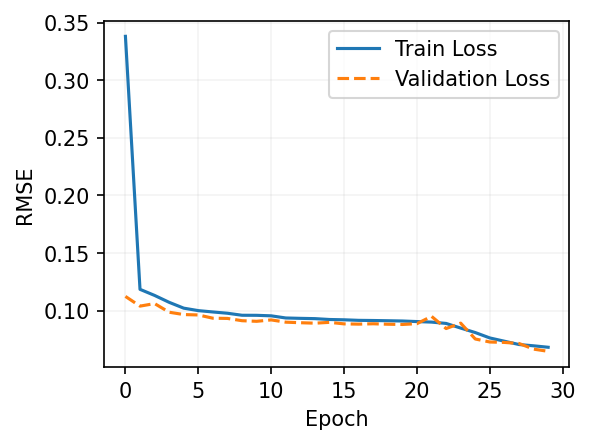

In [22]:
plt.figure(figsize=(4,3), dpi=150)
plt.plot(np.sqrt(train_losses), label='Train Loss')
plt.plot(np.sqrt(val_losses), label='Validation Loss', ls='dashed')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
# plt.ylim(0., 0.3)
plt.grid(alpha=0.15)
plt.legend()
plt.show()

#### Run some diagnostics

In [21]:
# def run_dataset_diagnostics(dataset, wave_grid, num_inspect=3):
#     """
#     Plots individual dataset samples and label distributions for quality control.
#     """
#     # 1. Target Label Distribution Check
#     all_y = [y.item() for _, y in dataset]
    
#     fig, axes = plt.subplots(1, 2, figsize=(14, 4))
#     axes[0].hist(all_y, bins=30, color='navy', alpha=0.7, edgecolor='black')
#     axes[0].set_xlabel(r'Target Label $\log_{10}(A)$')
#     axes[0].set_ylabel('Sample Count')
#     axes[0].set_title('Label Distribution Check')
#     axes[0].grid(True, alpha=0.3)
    
#     # SNR noise floor overlay reference
#     axes[1].scatter(range(len(all_y)), all_y, s=10, c=all_y, cmap='viridis', alpha=0.6)
#     axes[1].set_xlabel('Sample Index')
#     axes[1].set_ylabel(r'$\log_{10}(A)$')
#     axes[1].set_title('Sample Parameter Uniformity')
#     axes[1].grid(True, alpha=0.3)
#     plt.tight_layout()
#     plt.show()

#     # 2. Channel Overlay & Alignment Inspection
#     for idx in range(num_inspect):
#         X, y = dataset[idx]
#         tau_obs = X[0].numpy()
#         tau_shifted = X[1].numpy()
#         log10_A = y.item()
#         A_val = 10**log10_A

#         fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
        
#         # Upper Panel: Channel 0 vs Channel 1 on full grid
#         ax1.plot(wave_grid, tau_obs, label=r'Ch 0: $\tau_{obs}$ (Ly$\alpha$ + Metal)', color='black', lw=0.7, alpha=0.8)
#         ax1.plot(wave_grid, tau_shifted, label=r'Ch 1: $\tau_{shifted}$ (Shifted back)', color='crimson', lw=0.7, alpha=0.6)
#         ax1.set_ylabel(r'Optical Depth $\tau$')
#         ax1.set_title(f'Sample #{idx} | $\log_{{10}}(A) = {log10_A:.3f}$ ($A = {A_val:.4f}$)')
#         ax1.legend(loc='upper right')
#         ax1.grid(True, alpha=0.3)
        
#         # Lower Panel: Zoomed-in crop to verify feature alignment
#         # Pick a window in the middle of the wavelength coverage
#         mid_idx = len(wave_grid) // 2
#         zoom_range = slice(mid_idx, mid_idx + 800)
        
#         ax2.plot(wave_grid[zoom_range], tau_obs[zoom_range], color='black', lw=1.0, label=r'Ch 0 ($\tau_{obs}$)')
#         ax2.plot(wave_grid[zoom_range], tau_shifted[zoom_range], color='crimson', lw=1.0, alpha=0.7, label=r'Ch 1 ($\tau_{shifted}$)')
#         ax2.set_xlabel(r'Observed Wavelength ($\mathrm{\AA}$)')
#         ax2.set_ylabel(r'$\tau$ (Zoomed)')
#         ax2.legend(loc='upper right')
#         ax2.grid(True, alpha=0.3)
        
#         plt.tight_layout()
#         plt.show()

# # Run diagnostics on your generated dataset
# run_dataset_diagnostics(dataset, wave)

In [22]:
# def evaluate_spectral_cnn(model, val_loader, device, A_thresh=0.2):
#     model.eval()
#     y_true_list = []
#     y_pred_list = []

#     with torch.no_grad():
#         for X_b, y_b in val_loader:
#             X_b = X_b.to(device)
#             preds = model(X_b)
#             y_true_list.extend(y_b.numpy())
#             y_pred_list.extend(preds.cpu().numpy())

#     y_true = np.array(y_true_list)
#     y_pred = np.array(y_pred_list)
#     residuals = y_pred - y_true

#     # Convert back from log scale to physical linear A space
#     A_true = 10.0 ** y_true
#     A_pred = 10.0 ** y_pred

#     # Calculate metrics
#     mae = np.mean(np.abs(residuals))
#     rmse = np.sqrt(np.mean(residuals**2))

#     # --- 1. Parity and Residual Plots ---
#     fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#     # Parity plot
#     axes[0].scatter(y_true, y_pred, alpha=0.6, color="midnightblue", edgecolors="none", s=25)
#     axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], "r--", lw=2, label="1:1 Line")
#     axes[0].set_xlabel(r"True $\log_{10}(A)$")
#     axes[0].set_ylabel(r"Predicted $\log_{10}(A)$")
#     axes[0].set_title(f"Parity Plot (MAE: {mae:.4f}, RMSE: {rmse:.4f})")
#     axes[0].grid(True, alpha=0.3)
#     axes[0].legend()

#     # Residual plot
#     axes[1].scatter(y_true, residuals, alpha=0.6, color="crimson",
#                     edgecolors="none", s=25)
#     axes[1].axhline(0, color="black", linestyle="--", lw=1.5)
#     axes[1].set_xlabel(r"True $\log_{10}(A)$")
#     axes[1].set_ylabel(
#         r"Residual ($\log_{10}(A_{\mathrm{pred}}) - "
#         r"\log_{10}(A_{\mathrm{true}})$)"
#     )
#     axes[1].set_title("Residual Analysis")
#     axes[1].grid(True, alpha=0.3)

#     plt.tight_layout()
#     plt.show()

#     # --- 2. Purity & Completeness vs Detection Threshold ---
#     log_thresh_val = np.log10(A_thresh)
    
#     # Define boolean arrays for thresholding
#     is_true_metal = y_true >= log_thresh_val
#     is_pred_metal = y_pred >= log_thresh_val

#     tp = np.sum(is_true_metal & is_pred_metal)
#     fp = np.sum(~is_true_metal & is_pred_metal)
#     fn = np.sum(is_true_metal & ~is_pred_metal)
#     tn = np.sum(~is_true_metal & ~is_pred_metal)

#     purity = tp / (tp + fp) if (tp + fp) > 0 else 1.0
#     completeness = tp / (tp + fn) if (tp + fn) > 0 else 1.0

#     print(f"--- Performance @ Threshold A >= {A_thresh} (log10(A) >= {log_thresh_val:.2f}) ---")
#     print(f"True Positives:  {tp:3d} | False Positives: {fp:3d}")
#     print(f"False Negatives: {fn:3d} | True Negatives:  {tn:3d}")
#     print(f"Purity (Precision):     {purity:.4f}")
#     print(f"Completeness (Recall):  {completeness:.4f}")

#     # --- 3. Purity/Completeness Curves across Amplitude Sweep ---
#     threshold_sweep = np.linspace(y_true.min(), y_true.max(), 50)
#     purities = []
#     completenesses = []

#     for th in threshold_sweep:
#         t_pos = np.sum((y_true >= th) & (y_pred >= th))
#         f_pos = np.sum((y_true < th) & (y_pred >= th))
#         f_neg = np.sum((y_true >= th) & (y_pred < th))

#         pur = t_pos / (t_pos + f_pos) if (t_pos + f_pos) > 0 else 1.0
#         comp = t_pos / (t_pos + f_neg) if (t_pos + f_neg) > 0 else 1.0

#         purities.append(pur)
#         completenesses.append(comp)

#     plt.figure(figsize=(8, 4))
#     plt.plot(10**threshold_sweep, purities, label="Purity (Precision)", color="teal", lw=2)
#     plt.plot(10**threshold_sweep, completenesses, label="Completeness (Recall)", color="darkorange", lw=2)
#     plt.xlabel(r"Amplitude Threshold $A$")
#     plt.ylabel("Fraction")
#     plt.title("Purity & Completeness vs Amplitude Threshold")
#     plt.grid(True, alpha=0.3)
#     plt.legend()
#     plt.show()

# # Run evaluation on validation set
# evaluate_spectral_cnn(model, val_loader, device, A_thresh=0.2)

In [23]:
# def evaluate_multimetal_unet( # per pixel amplitude
#     model, 
#     val_loader, 
#     device, 
#     metal_names: list = None, 
#     prob_thresh: float = 0.5,
#     a_min: float = 0.2,
#     a_max: float = 1.0,
#     # log_a_min: float = -2.0,
#     # log_a_max: float = 0.0
# ):
#     """
#     Evaluates a pixel-level Multi-Metal 1D U-Net model.
#     Generates Parity, Residual, and Purity/Completeness plots per metal species.
#     """
#     model.eval()

#     log_a_min = np.log10(a_min)
#     log_a_max = np.log10(a_max)
    
#     all_mask_true = []
#     all_amp_true  = []
#     all_prob_pred = []
#     all_amp_pred  = []

#     with torch.no_grad():
#         for X_b, mask_b, amp_b in val_loader:
#             X_b = X_b.to(device)
#             logits_pred, amp_pred = model(X_b)
#             probs_pred = torch.sigmoid(logits_pred)

#             all_mask_true.append(mask_b.numpy())
#             all_amp_true.append(amp_b.numpy())
#             all_prob_pred.append(probs_pred.cpu().numpy())
#             all_amp_pred.append(amp_pred.cpu().numpy())

#     # Concatenate all validation batches -> shape: (N_samples, M_species, N_pixels)
#     mask_true = np.concatenate(all_mask_true, axis=0)
#     amp_true  = np.concatenate(all_amp_true, axis=0)
#     prob_pred = np.concatenate(all_prob_pred, axis=0)
#     amp_pred  = np.concatenate(all_amp_pred, axis=0)

#     num_species = mask_true.shape[1]
#     if metal_names is None:
#         metal_names = [f"Species_{i+1}" for i in range(num_species)]

#     # Iterate over each metal line species
#     for m_idx, species_name in enumerate(metal_names):
#         m_mask_true = mask_true[:, m_idx, :].flatten()
#         m_amp_true  = amp_true[:, m_idx, :].flatten()
#         m_prob_pred = prob_pred[:, m_idx, :].flatten()
#         m_amp_pred  = amp_pred[:, m_idx, :].flatten()

#         # Binary truth and predictions at current detection threshold
#         is_true = m_mask_true > 0.5
#         is_pred = m_prob_pred >= prob_thresh

#         # --- 1. Confusion Matrix Metrics ---
#         tp = np.sum(is_true & is_pred)
#         fp = np.sum(~is_true & is_pred)
#         fn = np.sum(is_true & ~is_pred)
#         tn = np.sum(~is_true & ~is_pred)

#         purity = tp / (tp + fp) if (tp + fp) > 0 else 0.0
#         completeness = tp / (tp + fn) if (tp + fn) > 0 else 0.0

#         print(f"\n" + "="*60)
#         print(f" Performance Metrics: {species_name} (Prob Threshold >= {prob_thresh})")
#         print(f"="*60)
#         print(f" True Positives (Pixels):  {tp:8d} | False Positives: {fp:8d}")
#         print(f" False Negatives (Pixels): {fn:8d} | True Negatives:  {tn:8d}")
#         print(f" Purity (Precision):       {purity:.4f}")
#         print(f" Completeness (Recall):    {completeness:.4f}")

#         # --- 2. Amplitude Recovery Metrics (Evaluated at Ground Truth Metal Pixels) ---
#         gt_true_amps = m_amp_true[is_true]
#         gt_pred_amps = m_amp_pred[is_true]

#         if len(gt_true_amps) > 0:
#             residuals = gt_pred_amps - gt_true_amps
#             mae = np.mean(np.abs(residuals))
#             rmse = np.sqrt(np.mean(residuals**2))
#             print(f" Amplitude MAE  [log10(A)]: {mae:.4f}")
#             print(f" Amplitude RMSE [log10(A)]: {rmse:.4f}")

#             # --- 3. Diagnostics Plotting (1x3 Panel per metal) ---
#             fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#             # Panel 1: Parity Plot
#             axes[0].scatter(gt_true_amps, gt_pred_amps, alpha=0.2, color="midnightblue", s=8, edgecolors="none")
#             axes[0].plot([log_a_min, log_a_max], [log_a_min, log_a_max], "r--", lw=2, label="1:1 Line")
#             axes[0].set_xlabel(r"True $\log_{10}(A)$")
#             axes[0].set_ylabel(r"Predicted $\log_{10}(A)$")
#             axes[0].set_title(f"{species_name} - Amplitude Parity\n(MAE: {mae:.4f}, RMSE: {rmse:.4f})")
#             axes[0].grid(True, alpha=0.3)
#             axes[0].legend()

#             # Panel 2: Residual Plot
#             axes[1].scatter(gt_true_amps, residuals, alpha=0.2, color="crimson", s=8, edgecolors="none")
#             axes[1].axhline(0, color="black", linestyle="--", lw=1.5)
#             axes[1].set_xlabel(r"True $\log_{10}(A)$")
#             axes[1].set_ylabel(r"Residual ($\log_{10}(A_{\mathrm{pred}}) - \log_{10}(A_{\mathrm{true}})$)")
#             axes[1].set_title(f"{species_name} - Residual Analysis")
#             axes[1].grid(True, alpha=0.3)

#             # Panel 3: Purity & Completeness Curves (Sweep over Probability Threshold)
#             prob_sweep = np.linspace(0.01, 0.99, 50)
#             purities, completenesses = [], []
#             for p_th in prob_sweep:
#                 pred_pos = m_prob_pred >= p_th
#                 tp_i = np.sum(is_true & pred_pos)
#                 fp_i = np.sum(~is_true & pred_pos)
#                 fn_i = np.sum(is_true & ~pred_pos)
                
#                 pur_i = tp_i / (tp_i + fp_i) if (tp_i + fp_i) > 0 else 1.0
#                 comp_i = tp_i / (tp_i + fn_i) if (tp_i + fn_i) > 0 else 1.0
#                 purities.append(pur_i)
#                 completenesses.append(comp_i)

#             axes[2].plot(prob_sweep, purities, label="Purity (Precision)", color="teal", lw=2)
#             axes[2].plot(prob_sweep, completenesses, label="Completeness (Recall)", color="darkorange", lw=2)
#             axes[2].axvline(prob_thresh, color="gray", linestyle=":", label=f"Current Thresh ({prob_thresh})")
#             axes[2].set_xlabel("Detection Probability Threshold")
#             axes[2].set_ylabel("Fraction")
#             axes[2].set_title(f"{species_name} - Purity & Completeness")
#             axes[2].grid(True, alpha=0.3)
#             axes[2].legend()

#             plt.tight_layout()
#             plt.show()

In [24]:
# def evaluate_multimetal_unet(
#     model, 
#     val_loader, 
#     device, 
#     metal_names: list = None, 
#     prob_thresh: float = 0.5,
#     a_min: float = 0.2,
#     a_max: float = 1.0,
# ):
#     """
#     Evaluates a pixel-level Multi-Metal 1D U-Net model.
#     Generates a 2x2 panel per metal species with Hexbin plots and TP filtering.
#     """
#     model.eval()

#     log_a_min = np.log10(a_min)
#     log_a_max = np.log10(a_max)
    
#     all_mask_true = []
#     all_amp_true  = []
#     all_prob_pred = []
#     all_amp_pred  = []

#     with torch.no_grad():
#         for X_b, mask_b, amp_b in val_loader:
#             X_b = X_b.to(device)
#             logits_pred, amp_pred = model(X_b)
#             probs_pred = torch.sigmoid(logits_pred)

#             all_mask_true.append(mask_b.numpy())
#             all_amp_true.append(amp_b.numpy())
#             all_prob_pred.append(probs_pred.cpu().numpy())
#             all_amp_pred.append(amp_pred.cpu().numpy())

#     # Concatenate all validation batches -> shape: (N_samples, M_species, N_pixels)
#     mask_true = np.concatenate(all_mask_true, axis=0)
#     amp_true  = np.concatenate(all_amp_true, axis=0)
#     prob_pred = np.concatenate(all_prob_pred, axis=0)
#     amp_pred  = np.concatenate(all_amp_pred, axis=0)

#     num_species = mask_true.shape[1]
#     if metal_names is None:
#         metal_names = [f"Species_{i+1}" for i in range(num_species)]

#     # Iterate over each metal line species
#     for m_idx, species_name in enumerate(metal_names):
#         m_mask_true = mask_true[:, m_idx, :].flatten()
#         m_amp_true  = amp_true[:, m_idx, :].flatten()
#         m_prob_pred = prob_pred[:, m_idx, :].flatten()
#         m_amp_pred  = amp_pred[:, m_idx, :].flatten()

#         # Binary truth and predictions at current detection threshold
#         is_true = m_mask_true > 0.5
#         is_pred = m_prob_pred >= prob_thresh
#         is_tp   = is_true & is_pred  # True Positives

#         # --- 1. Confusion Matrix Metrics ---
#         tp = np.sum(is_tp)
#         fp = np.sum(~is_true & is_pred)
#         fn = np.sum(is_true & ~is_pred)
#         tn = np.sum(~is_true & ~is_pred)

#         purity = tp / (tp + fp) if (tp + fp) > 0 else 0.0
#         completeness = tp / (tp + fn) if (tp + fn) > 0 else 0.0

#         print(f"\n" + "="*60)
#         print(f" Performance Metrics: {species_name} (Prob Threshold >= {prob_thresh})")
#         print(f"="*60)
#         print(f" True Positives (Pixels):  {tp:8d} | False Positives: {fp:8d}")
#         print(f" False Negatives (Pixels): {fn:8d} | True Negatives:  {tn:8d}")
#         print(f" Purity (Precision):       {purity:.4f}")
#         print(f" Completeness (Recall):    {completeness:.4f}")

#         # Ground Truth arrays vs True Positive arrays
#         gt_true_amps = m_amp_true[is_true]
#         gt_pred_amps = m_amp_pred[is_true]
        
#         tp_true_amps = m_amp_true[is_tp]
#         tp_pred_amps = m_amp_pred[is_tp]

#         if len(gt_true_amps) > 0:
#             # Metrics on all GT pixels
#             gt_residuals = gt_pred_amps - gt_true_amps
#             gt_mae = np.mean(np.abs(gt_residuals))
#             gt_rmse = np.sqrt(np.mean(gt_residuals**2))
            
#             # Metrics on detected pixels only (True Positives)
#             if len(tp_true_amps) > 0:
#                 tp_residuals = tp_pred_amps - tp_true_amps
#                 tp_mae = np.mean(np.abs(tp_residuals))
#                 tp_rmse = np.sqrt(np.mean(tp_residuals**2))
#             else:
#                 tp_residuals, tp_mae, tp_rmse = np.array([]), 0.0, 0.0

#             print(f" All GT Pixels Amplitude MAE  [log10(A)]: {gt_mae:.4f}")
#             print(f" Detected (TP) Pixels Amp MAE [log10(A)]: {tp_mae:.4f}")

#             # --- 2. Diagnostics Plotting (2x2 Panel per metal) ---
#             fig, axes = plt.subplots(2, 2, figsize=(13, 11))

#             # Panel 1 (Top-Left): All Ground Truth Pixels Parity
#             hb0 = axes[0, 0].hexbin(
#                 gt_true_amps, gt_pred_amps, gridsize=50, cmap="viridis", mincnt=1, bins='log'
#             )
#             axes[0, 0].plot([log_a_min, log_a_max], [log_a_min, log_a_max], "r--", lw=2, label="1:1 Line")
#             axes[0, 0].set_xlabel(r"True $\log_{10}(A)$")
#             axes[0, 0].set_ylabel(r"Predicted $\log_{10}(A)$")
#             axes[0, 0].set_title(f"All Ground Truth Pixels (N={len(gt_true_amps)})\nMAE: {gt_mae:.4f}, RMSE: {gt_rmse:.4f}")
#             axes[0, 0].grid(True, alpha=0.3)
#             axes[0, 0].legend(loc="upper left")
#             fig.colorbar(hb0, ax=axes[0, 0], label=r"$\log_{10}(\mathrm{Pixel\ Count})$")

#             # Panel 2 (Top-Right): True Positives Only Parity (Detected Pixels)
#             if len(tp_true_amps) > 0:
#                 hb1 = axes[0, 1].hexbin(
#                     tp_true_amps, tp_pred_amps, gridsize=50, cmap="plasma", mincnt=1, bins='log'
#                 )
#                 axes[0, 1].plot([log_a_min, log_a_max], [log_a_min, log_a_max], "r--", lw=2, label="1:1 Line")
#                 axes[0, 1].set_xlabel(r"True $\log_{10}(A)$")
#                 axes[0, 1].set_ylabel(r"Predicted $\log_{10}(A)$")
#                 axes[0, 1].set_title(f"Detected Pixels Only (TPs, N={len(tp_true_amps)})\nMAE: {tp_mae:.4f}, RMSE: {tp_rmse:.4f}")
#                 axes[0, 1].grid(True, alpha=0.3)
#                 axes[0, 1].legend(loc="upper left")
#                 fig.colorbar(hb1, ax=axes[0, 1], label=r"$\log_{10}(\mathrm{Pixel\ Count})$")
#             else:
#                 axes[0, 1].text(0.5, 0.5, "No True Positives Detected", ha='center', va='center')

#             # Panel 3 (Bottom-Left): Residual Analysis on True Positives
#             if len(tp_true_amps) > 0:
#                 hb2 = axes[1, 0].hexbin(
#                     tp_true_amps, tp_residuals, gridsize=50, cmap="coolwarm", mincnt=1, bins='log'
#                 )
#                 axes[1, 0].axhline(0, color="black", linestyle="--", lw=1.5)
#                 axes[1, 0].set_xlabel(r"True $\log_{10}(A)$")
#                 axes[1, 0].set_ylabel(r"Residual ($\log_{10}(A_{\mathrm{pred}}) - \log_{10}(A_{\mathrm{true}})$)")
#                 axes[1, 0].set_title("Detected Pixels (TP) - Residual Analysis")
#                 axes[1, 0].grid(True, alpha=0.3)
#                 fig.colorbar(hb2, ax=axes[1, 0], label=r"$\log_{10}(\mathrm{Pixel\ Count})$")
#             else:
#                 axes[1, 0].text(0.5, 0.5, "No True Positives Detected", ha='center', va='center')

#             # Panel 4 (Bottom-Right): Purity & Completeness Curves
#             prob_sweep = np.linspace(0.01, 0.99, 50)
#             purities, completenesses = [], []
#             for p_th in prob_sweep:
#                 pred_pos = m_prob_pred >= p_th
#                 tp_i = np.sum(is_true & pred_pos)
#                 fp_i = np.sum(~is_true & pred_pos)
#                 fn_i = np.sum(is_true & ~pred_pos)
                
#                 pur_i = tp_i / (tp_i + fp_i) if (tp_i + fp_i) > 0 else 1.0
#                 comp_i = tp_i / (tp_i + fn_i) if (tp_i + fn_i) > 0 else 1.0
#                 purities.append(pur_i)
#                 completenesses.append(comp_i)

#             axes[1, 1].plot(prob_sweep, purities, label="Purity (Precision)", color="teal", lw=2)
#             axes[1, 1].plot(prob_sweep, completenesses, label="Completeness (Recall)", color="darkorange", lw=2)
#             axes[1, 1].axvline(prob_thresh, color="gray", linestyle=":", label=f"Current Thresh ({prob_thresh})")
#             axes[1, 1].set_xlabel("Detection Probability Threshold")
#             axes[1, 1].set_ylabel("Fraction")
#             axes[1, 1].set_title("Purity & Completeness Curves")
#             axes[1, 1].grid(True, alpha=0.3)
#             axes[1, 1].legend(loc="best")

#             plt.suptitle(f"Diagnostic Summary: {species_name}", fontsize=14, y=0.99)
#             plt.tight_layout()
#             plt.show()

In [25]:
# # note: purity / completeness are per pixel

# def evaluate_multimetal_unet(
#     model, 
#     val_loader, 
#     device, 
#     metal_names: list = None, 
#     prob_thresh: float = 0.5,
#     a_min: float = 0.2,
#     a_max: float = 1.0,
# ):
#     """
#     Evaluates a pixel-level Multi-Metal 1D U-Net model and aggregates predictions 
#     to per-spectrum and dataset-level single amplitude metrics.
#     """
#     model.eval()

#     log_a_min = np.log10(a_min)
#     log_a_max = np.log10(a_max)
    
#     all_mask_true = []
#     all_amp_true  = []
#     all_prob_pred = []
#     all_amp_pred  = []

#     with torch.no_grad():
#         for X_b, mask_b, amp_b in val_loader:
#             X_b = X_b.to(device)
#             logits_pred, amp_pred = model(X_b)
#             probs_pred = torch.sigmoid(logits_pred)

#             all_mask_true.append(mask_b.cpu().numpy())
#             all_amp_true.append(amp_b.cpu().numpy())
#             all_prob_pred.append(probs_pred.cpu().numpy())
#             all_amp_pred.append(amp_pred.cpu().numpy())

#     # Stack shapes -> (N_spectra, M_species, N_pixels)
#     mask_true = np.concatenate(all_mask_true, axis=0)
#     amp_true  = np.concatenate(all_amp_true, axis=0)
#     prob_pred = np.concatenate(all_prob_pred, axis=0)
#     amp_pred  = np.concatenate(all_amp_pred, axis=0)

#     num_spectra, num_species, num_pixels = mask_true.shape
#     if metal_names is None:
#         metal_names = [f"Species_{i+1}" for i in range(num_species)]

#     for m_idx, species_name in enumerate(metal_names):
#         # Flattened arrays for pixel-level metrics
#         m_mask_true = mask_true[:, m_idx, :].flatten()
#         m_amp_true  = amp_true[:, m_idx, :].flatten()
#         m_prob_pred = prob_pred[:, m_idx, :].flatten()
#         m_amp_pred  = amp_pred[:, m_idx, :].flatten()

#         is_true = m_mask_true > 0.5
#         is_pred = m_prob_pred >= prob_thresh
#         is_tp   = is_true & is_pred

#         # --- 1. Pixel-Level Classification Metrics ---
#         tp = np.sum(is_tp)
#         fp = np.sum(~is_true & is_pred)
#         fn = np.sum(is_true & ~is_pred)
#         tn = np.sum(~is_true & ~is_pred)

#         purity = tp / (tp + fp) if (tp + fp) > 0 else 0.0
#         completeness = tp / (tp + fn) if (tp + fn) > 0 else 0.0

#         # --- 2. Per-Spectrum & Dataset-Level Aggregations ---
#         spec_true_amps = []
#         spec_pred_amps_tp = []  # Evaluated on detected TP pixels in spectrum
#         spec_pred_amps_gt = []  # Evaluated on all GT line pixels in spectrum

#         spectra_with_metal = 0
#         spectra_detected = 0

#         for s_idx in range(num_spectra):
#             gt_pixels = mask_true[s_idx, m_idx, :] > 0.5
#             tp_pixels = gt_pixels & (prob_pred[s_idx, m_idx, :] >= prob_thresh)

#             if np.any(gt_pixels):
#                 spectra_with_metal += 1
#                 # Extract single ground-truth amplitude for this spectrum (median over feature pixels)
#                 a_true_spec = np.median(amp_true[s_idx, m_idx, gt_pixels])
#                 a_pred_gt_spec = np.median(amp_pred[s_idx, m_idx, gt_pixels])

#                 spec_true_amps.append(a_true_spec)
#                 spec_pred_amps_gt.append(a_pred_gt_spec)

#                 if np.any(tp_pixels):
#                     spectra_detected += 1
#                     a_pred_tp_spec = np.median(amp_pred[s_idx, m_idx, tp_pixels])
#                     spec_pred_amps_tp.append((a_true_spec, a_pred_tp_spec))

#         spec_true_amps = np.array(spec_true_amps)
#         spec_pred_amps_gt = np.array(spec_pred_amps_gt)
        
#         if len(spec_pred_amps_tp) > 0:
#             tp_spec_true, tp_spec_pred = zip(*spec_pred_amps_tp)
#             tp_spec_true, tp_spec_pred = np.array(tp_spec_true), np.array(tp_spec_pred)
#         else:
#             tp_spec_true, tp_spec_pred = np.array([]), np.array([])

#         # Calculate Spectrum-Level MAE/RMSE
#         spec_gt_mae = np.mean(np.abs(spec_pred_amps_gt - spec_true_amps)) if len(spec_true_amps) > 0 else 0.0
#         spec_tp_mae = np.mean(np.abs(tp_spec_pred - tp_spec_true)) if len(tp_spec_true) > 0 else 0.0

#         # Calculate Dataset-Level Aggregates
#         dataset_true_median = np.median(spec_true_amps) if len(spec_true_amps) > 0 else 0.0
#         dataset_true_mean   = np.mean(spec_true_amps) if len(spec_true_amps) > 0 else 0.0
        
#         dataset_pred_tp_median = np.median(tp_spec_pred) if len(tp_spec_pred) > 0 else 0.0
#         dataset_pred_tp_mean   = np.mean(tp_spec_pred) if len(tp_spec_pred) > 0 else 0.0

#         # --- 3. Print Comprehensive Metrics ---
#         print("\n" + "="*70)
#         print(f" PERFORMANCE METRICS: {species_name} (Prob Threshold >= {prob_thresh})")
#         print("="*70)
#         print(" PIXEL-LEVEL CLASSIFICATION:")
#         print(f"  True Positives:  {tp:8d} | False Positives: {fp:8d}")
#         print(f"  False Negatives: {fn:8d} | True Negatives:  {tn:8d}")
#         print(f"  Purity (Precision):    {purity:.4f}")
#         print(f"  Completeness (Recall): {completeness:.4f}")
#         print("-" * 70)
#         print(" SPECTRUM-LEVEL SUMMARY (Single Amplitude per Spectrum):")
#         print(f"  Spectra containing metal:  {spectra_with_metal:4d} / {num_spectra}")
#         print(f"  Spectra detected (>=1 TP): {spectra_detected:4d} / {spectra_with_metal}")
#         print(f"  Spectrum-level MAE (All GT lines):    {spec_gt_mae:.4f} log10(A)")
#         print(f"  Spectrum-level MAE (Detected TPs only): {spec_tp_mae:.4f} log10(A)")
#         print("-" * 70)
#         print(" DATASET-LEVEL AGGREGATE METRICS:")
#         print(f"  True Dataset Amplitude  -> Median: {dataset_true_median:.4f} | Mean: {dataset_true_mean:.4f}")
#         print(f"  Pred Dataset Amplitude  -> Median: {dataset_pred_tp_median:.4f} | Mean: {dataset_pred_tp_mean:.4f}")
#         print(f"              Difference  -> Median: {np.abs(dataset_pred_tp_median-dataset_true_median):.4f} | Mean: {np.abs(dataset_pred_tp_mean-dataset_true_mean):.4f}")
#         print(f"  Global Dataset Bias (Pred - True Median): {dataset_pred_tp_median - dataset_true_median:+.4f} log10(A)")
#         print("="*70)

#         # --- 4. Diagnostics Plotting (2x2 Panel per metal) ---
#         gt_true_amps = m_amp_true[is_true]
#         gt_pred_amps = m_amp_pred[is_true]
#         tp_true_amps = m_amp_true[is_tp]
#         tp_pred_amps = m_amp_pred[is_tp]

#         fig, axes = plt.subplots(2, 2, figsize=(13, 11))

#         # Panel 1: Pixel-Level Parity (All GT)
#         hb0 = axes[0, 0].hexbin(
#             gt_true_amps, gt_pred_amps, gridsize=50, cmap="viridis", mincnt=1, bins='log'
#         )
#         axes[0, 0].plot([log_a_min, log_a_max], [log_a_min, log_a_max], "r--", lw=2, label="1:1 Line")
#         axes[0, 0].set_xlabel(r"True $\log_{10}(A)$")
#         axes[0, 0].set_ylabel(r"Predicted $\log_{10}(A)$")
#         axes[0, 0].set_title(f"Pixel-Level: All GT Pixels\n(MAE: {np.mean(np.abs(gt_pred_amps - gt_true_amps)):.4f})")
#         axes[0, 0].grid(True, alpha=0.3)
#         axes[0, 0].legend(loc="upper left")
#         fig.colorbar(hb0, ax=axes[0, 0], label=r"$\log_{10}(\mathrm{Pixel\ Count})$")

#         # Panel 2: Spectrum-Level Parity (Aggregated 1 Amplitude per Spectrum)
#         if len(tp_spec_true) > 0:
#             hb1 = axes[0, 1].hexbin(
#                 tp_spec_true, tp_spec_pred, gridsize=30, cmap="plasma", mincnt=1, bins='log'
#             )
#             axes[0, 1].plot([log_a_min, log_a_max], [log_a_min, log_a_max], "r--", lw=2, label="1:1 Line")
#             axes[0, 1].axhline(dataset_pred_tp_median, color="purple", linestyle=":", label=f"Pred Median ({dataset_pred_tp_median:.2f})")
#             axes[0, 1].axvline(dataset_true_median, color="black", linestyle=":", label=f"True Median ({dataset_true_median:.2f})")
#             axes[0, 1].set_xlabel(r"True Spectrum $\log_{10}(A)$")
#             axes[0, 1].set_ylabel(r"Predicted Spectrum $\log_{10}(A)$")
#             axes[0, 1].set_title(f"Spectrum-Level: Aggregated 1 value/spectrum\n(MAE: {spec_tp_mae:.4f})")
#             axes[0, 1].grid(True, alpha=0.3)
#             axes[0, 1].legend(loc="upper left")
#             fig.colorbar(hb1, ax=axes[0, 1], label=r"$\log_{10}(\mathrm{Spectrum\ Count})$")
#         else:
#             axes[0, 1].text(0.5, 0.5, "No Detected Spectra", ha='center', va='center')

#         # Panel 3: True Positives Pixel Residuals
#         if len(tp_true_amps) > 0:
#             tp_residuals = tp_pred_amps - tp_true_amps
#             hb2 = axes[1, 0].hexbin(
#                 tp_true_amps, tp_residuals, gridsize=50, cmap="coolwarm", mincnt=1, bins='log'
#             )
#             axes[1, 0].axhline(0, color="black", linestyle="--", lw=1.5)
#             axes[1, 0].set_xlabel(r"True $\log_{10}(A)$")
#             axes[1, 0].set_ylabel(r"Residual ($\log_{10}(A_{\mathrm{pred}}) - \log_{10}(A_{\mathrm{true}})$)")
#             axes[1, 0].set_title("Pixel-Level: TP Residuals")
#             axes[1, 0].grid(True, alpha=0.3)
#             fig.colorbar(hb2, ax=axes[1, 0], label=r"$\log_{10}(\mathrm{Pixel\ Count})$")
#         else:
#             axes[1, 0].text(0.5, 0.5, "No True Positives", ha='center', va='center')

#         # Panel 4: Purity & Completeness Curves
#         prob_sweep = np.linspace(0.01, 0.99, 50)
#         purities, completenesses = [], []
#         for p_th in prob_sweep:
#             pred_pos = m_prob_pred >= p_th
#             tp_i = np.sum(is_true & pred_pos)
#             fp_i = np.sum(~is_true & pred_pos)
#             fn_i = np.sum(is_true & ~pred_pos)
            
#             purities.append(tp_i / (tp_i + fp_i) if (tp_i + fp_i) > 0 else 1.0)
#             completenesses.append(tp_i / (tp_i + fn_i) if (tp_i + fn_i) > 0 else 1.0)

#         axes[1, 1].plot(prob_sweep, purities, label="Purity", color="teal", lw=2)
#         axes[1, 1].plot(prob_sweep, completenesses, label="Completeness", color="darkorange", lw=2)
#         axes[1, 1].axvline(prob_thresh, color="gray", linestyle=":", label=f"Thresh ({prob_thresh})")
#         axes[1, 1].set_xlabel("Detection Probability Threshold")
#         axes[1, 1].set_ylabel("Fraction")
#         axes[1, 1].set_title("Purity & Completeness Curves")
#         axes[1, 1].grid(True, alpha=0.3)
#         axes[1, 1].legend(loc="best")

#         plt.suptitle(f"Diagnostic Summary: {species_name}", fontsize=14, y=0.99)
#         plt.tight_layout()
#         plt.show()

In [26]:
def evaluate_multimetal_unet( # note: puity / completeness are per pixel
    model, 
    val_loader, 
    device, 
    metal_names: list = None, 
    prob_thresh: float = 0.5,
    a_min: float = 0.2,
    a_max: float = 1.0,
):
    """
    Evaluates a pixel-level Multi-Metal 1D U-Net model and aggregates predictions 
    to per-spectrum and dataset-level single amplitude metrics.
    """
    model.eval()

    log_a_min = np.log10(a_min)
    log_a_max = np.log10(a_max)
    
    all_mask_true = []
    all_amp_true  = []
    all_prob_pred = []
    all_amp_pred  = []

    with torch.no_grad():
        for X_b, mask_b, amp_b in val_loader:
            X_b = X_b.to(device)
            logits_pred, amp_pred = model(X_b)
            probs_pred = torch.sigmoid(logits_pred)

            all_mask_true.append(mask_b.cpu().numpy())
            all_amp_true.append(amp_b.cpu().numpy())
            all_prob_pred.append(probs_pred.cpu().numpy())
            all_amp_pred.append(amp_pred.cpu().numpy())

    # Stack shapes -> (N_spectra, M_species, N_pixels)
    mask_true = np.concatenate(all_mask_true, axis=0)
    amp_true  = np.concatenate(all_amp_true, axis=0)
    prob_pred = np.concatenate(all_prob_pred, axis=0)
    amp_pred  = np.concatenate(all_amp_pred, axis=0)

    num_spectra, num_species, num_pixels = mask_true.shape
    if metal_names is None:
        metal_names = [f"Species_{i+1}" for i in range(num_species)]

    for m_idx, species_name in enumerate(metal_names):
        # Flattened arrays for pixel-level metrics
        m_mask_true = mask_true[:, m_idx, :].flatten()
        m_amp_true  = amp_true[:, m_idx, :].flatten()
        m_prob_pred = prob_pred[:, m_idx, :].flatten()
        m_amp_pred  = amp_pred[:, m_idx, :].flatten()

        is_true = m_mask_true > 0.5
        is_pred = m_prob_pred >= prob_thresh
        is_tp   = is_true & is_pred

        # --- 1. Pixel-Level Classification Metrics ---
        tp = np.sum(is_tp)
        fp = np.sum(~is_true & is_pred)
        fn = np.sum(is_true & ~is_pred)
        tn = np.sum(~is_true & ~is_pred)

        purity = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        completeness = tp / (tp + fn) if (tp + fn) > 0 else 0.0

        # --- 2. Per-Spectrum & Dataset-Level Aggregations ---
        spec_true_amps = []
        spec_pred_amps_tp = []  # Evaluated on detected TP pixels in spectrum
        spec_pred_amps_gt = []  # Evaluated on all GT line pixels in spectrum

        spectra_with_metal = 0
        spectra_detected = 0

        for s_idx in range(num_spectra):
            gt_pixels = mask_true[s_idx, m_idx, :] > 0.5
            tp_pixels = gt_pixels & (prob_pred[s_idx, m_idx, :] >= prob_thresh)

            if np.any(gt_pixels):
                spectra_with_metal += 1
                # Extract single ground-truth amplitude for this spectrum (median over feature pixels)
                a_true_spec = np.median(amp_true[s_idx, m_idx, gt_pixels])
                a_pred_gt_spec = np.median(amp_pred[s_idx, m_idx, gt_pixels])

                spec_true_amps.append(a_true_spec)
                spec_pred_amps_gt.append(a_pred_gt_spec)

                if np.any(tp_pixels):
                    spectra_detected += 1
                    a_pred_tp_spec = np.median(amp_pred[s_idx, m_idx, tp_pixels])
                    spec_pred_amps_tp.append((a_true_spec, a_pred_tp_spec))

        spec_true_amps = np.array(spec_true_amps)
        spec_pred_amps_gt = np.array(spec_pred_amps_gt)
        
        if len(spec_pred_amps_tp) > 0:
            tp_spec_true, tp_spec_pred = zip(*spec_pred_amps_tp)
            tp_spec_true, tp_spec_pred = np.array(tp_spec_true), np.array(tp_spec_pred)
        else:
            tp_spec_true, tp_spec_pred = np.array([]), np.array([])

        # Calculate Spectrum-Level MAE/RMSE
        spec_gt_mae = np.mean(np.abs(spec_pred_amps_gt - spec_true_amps)) if len(spec_true_amps) > 0 else 0.0
        spec_tp_mae = np.mean(np.abs(tp_spec_pred - tp_spec_true)) if len(tp_spec_true) > 0 else 0.0

        # Calculate Dataset-Level Aggregates
        dataset_true_median = np.median(spec_true_amps) if len(spec_true_amps) > 0 else 0.0
        dataset_true_mean   = np.mean(spec_true_amps) if len(spec_true_amps) > 0 else 0.0
        
        dataset_pred_tp_median = np.median(tp_spec_pred) if len(tp_spec_pred) > 0 else 0.0
        dataset_pred_tp_mean   = np.mean(tp_spec_pred) if len(tp_spec_pred) > 0 else 0.0

        # --- 3. Print Comprehensive Metrics ---
        print("\n" + "="*70)
        print(f" PERFORMANCE METRICS: {species_name} (Prob Threshold >= {prob_thresh})")
        print("="*70)
        print(" PIXEL-LEVEL CLASSIFICATION:")
        print(f"  True Positives:  {tp:8d} | False Positives: {fp:8d}")
        print(f"  False Negatives: {fn:8d} | True Negatives:  {tn:8d}")
        print(f"  Purity (Precision):    {purity:.4f}")
        print(f"  Completeness (Recall): {completeness:.4f}")
        print("-" * 70)
        print(" SPECTRUM-LEVEL SUMMARY (Single Amplitude per Spectrum):")
        print(f"  Spectra containing metal:  {spectra_with_metal:4d} / {num_spectra}")
        print(f"  Spectra detected (>=1 TP): {spectra_detected:4d} / {spectra_with_metal}")
        print(f"  Spectrum-level MAE (All GT lines):    {spec_gt_mae:.4f} log10(A)")
        print(f"  Spectrum-level MAE (Detected TPs only): {spec_tp_mae:.4f} log10(A)")
        print("-" * 70)
        print(" DATASET-LEVEL AGGREGATE METRICS:")
        print(f"  True Dataset Amplitude  -> Median: {dataset_true_median:.4f} | Mean: {dataset_true_mean:.4f}")
        print(f"  Pred Dataset Amplitude  -> Median: {dataset_pred_tp_median:.4f} | Mean: {dataset_pred_tp_mean:.4f}")
        print(f"              Difference  -> Median: {np.abs(dataset_pred_tp_median-dataset_true_median):.4f} | Mean: {np.abs(dataset_pred_tp_mean-dataset_true_mean):.4f}")
        print(f"  Global Dataset Bias (Pred - True Median): {dataset_pred_tp_median - dataset_true_median:+.4f} log10(A)")
        print("="*70)

        # --- 4. Diagnostics Plotting (2x2 Panel per metal) ---
        gt_true_amps = m_amp_true[is_true]
        gt_pred_amps = m_amp_pred[is_true]
        tp_true_amps = m_amp_true[is_tp]
        tp_pred_amps = m_amp_pred[is_tp]

        fig, axes = plt.subplots(2, 2, figsize=(13, 11))

        # Panel 1: Pixel-Level Parity (All GT)
        hb0 = axes[0, 0].hexbin(
            gt_true_amps, gt_pred_amps, gridsize=50, cmap="viridis", mincnt=1, bins='log'
        )
        axes[0, 0].plot([log_a_min, log_a_max], [log_a_min, log_a_max], "r--", lw=2, label="1:1 Line")
        axes[0, 0].set_xlabel(r"True $\log_{10}(A)$")
        axes[0, 0].set_ylabel(r"Predicted $\log_{10}(A)$")
        axes[0, 0].set_title(f"Pixel-Level: All GT Pixels\n(MAE: {np.mean(np.abs(gt_pred_amps - gt_true_amps)):.4f})")
        axes[0, 0].grid(True, alpha=0.3)
        axes[0, 0].legend(loc="upper left")
        fig.colorbar(hb0, ax=axes[0, 0], label=r"$\log_{10}(\mathrm{Pixel\ Count})$")

        # Panel 2: Spectrum-Level Parity (Aggregated 1 Amplitude per Spectrum)
        if len(tp_spec_true) > 0:
            hb1 = axes[0, 1].hexbin(
                tp_spec_true, tp_spec_pred, gridsize=30, cmap="plasma", mincnt=1, bins='log'
            )
            axes[0, 1].plot([log_a_min, log_a_max], [log_a_min, log_a_max], "r--", lw=2, label="1:1 Line")
            axes[0, 1].axhline(dataset_pred_tp_median, color="purple", linestyle=":", label=f"Pred Median ({dataset_pred_tp_median:.2f})")
            axes[0, 1].axvline(dataset_true_median, color="black", linestyle=":", label=f"True Median ({dataset_true_median:.2f})")
            axes[0, 1].set_xlabel(r"True Spectrum $\log_{10}(A)$")
            axes[0, 1].set_ylabel(r"Predicted Spectrum $\log_{10}(A)$")
            axes[0, 1].set_title(f"Spectrum-Level: Aggregated 1 value/spectrum\n(MAE: {spec_tp_mae:.4f})")
            axes[0, 1].grid(True, alpha=0.3)
            axes[0, 1].legend(loc="upper left")
            fig.colorbar(hb1, ax=axes[0, 1], label=r"$\log_{10}(\mathrm{Spectrum\ Count})$")
        else:
            axes[0, 1].text(0.5, 0.5, "No Detected Spectra", ha='center', va='center')

        # Panel 3: True Positives Pixel Residuals
        if len(tp_true_amps) > 0:
            tp_residuals = tp_pred_amps - tp_true_amps
            hb2 = axes[1, 0].hexbin(
                tp_true_amps, tp_residuals, gridsize=50, cmap="coolwarm", mincnt=1, bins='log'
            )
            axes[1, 0].axhline(0, color="black", linestyle="--", lw=1.5)
            axes[1, 0].set_xlabel(r"True $\log_{10}(A)$")
            axes[1, 0].set_ylabel(r"Residual ($\log_{10}(A_{\mathrm{pred}}) - \log_{10}(A_{\mathrm{true}})$)")
            axes[1, 0].set_title("Pixel-Level: TP Residuals")
            axes[1, 0].grid(True, alpha=0.3)
            fig.colorbar(hb2, ax=axes[1, 0], label=r"$\log_{10}(\mathrm{Pixel\ Count})$")
        else:
            axes[1, 0].text(0.5, 0.5, "No True Positives", ha='center', va='center')

        # Panel 4: Purity & Completeness Curves
        prob_sweep = np.linspace(0.01, 0.99, 50)
        purities, completenesses = [], []
        for p_th in prob_sweep:
            pred_pos = m_prob_pred >= p_th
            tp_i = np.sum(is_true & pred_pos)
            fp_i = np.sum(~is_true & pred_pos)
            fn_i = np.sum(is_true & ~pred_pos)
            
            purities.append(tp_i / (tp_i + fp_i) if (tp_i + fp_i) > 0 else 1.0)
            completenesses.append(tp_i / (tp_i + fn_i) if (tp_i + fn_i) > 0 else 1.0)

        axes[1, 1].plot(prob_sweep, purities, label="Purity", color="teal", lw=2)
        axes[1, 1].plot(prob_sweep, completenesses, label="Completeness", color="darkorange", lw=2)
        axes[1, 1].axvline(prob_thresh, color="gray", linestyle=":", label=f"Thresh ({prob_thresh})")
        axes[1, 1].set_xlabel("Detection Probability Threshold")
        axes[1, 1].set_ylabel("Fraction")
        axes[1, 1].set_title("Purity & Completeness Curves")
        axes[1, 1].grid(True, alpha=0.3)
        axes[1, 1].legend(loc="best")

        plt.suptitle(f"Diagnostic Summary: {species_name}", fontsize=14, y=0.99)
        plt.tight_layout()
        plt.show()

In [27]:
def evaluate_fixed_amplitude_unet(
    model, 
    val_loader, 
    device, 
    metal_names: list = None, 
    prob_thresh: float = 0.5,
    inputs_in_log_space: bool = True,
):
    """
    Evaluates a 1D U-Net on a dataset with fixed single-amplitude metal lines per species.
    Reports all metrics and generates plots in linear amplitude units A.
    """
    model.eval()

    all_mask_true = []
    all_amp_true  = []
    all_prob_pred = []
    all_amp_pred  = []

    with torch.no_grad():
        for X_b, mask_b, amp_b in val_loader:
            X_b = X_b.to(device)
            logits_pred, amp_pred = model(X_b)
            probs_pred = torch.sigmoid(logits_pred)

            all_mask_true.append(mask_b.cpu().numpy())
            all_amp_true.append(amp_b.cpu().numpy())
            all_prob_pred.append(probs_pred.cpu().numpy())
            all_amp_pred.append(amp_pred.cpu().numpy())

    # Stack shapes -> (N_spectra, M_species, N_pixels)
    mask_true = np.concatenate(all_mask_true, axis=0)
    amp_true  = np.concatenate(all_amp_true, axis=0)
    prob_pred = np.concatenate(all_prob_pred, axis=0)
    amp_pred  = np.concatenate(all_amp_pred, axis=0)

    # Convert from log10 space to linear amplitude A if needed
    if inputs_in_log_space:
        amp_true = 10.0 ** amp_true
        amp_pred = 10.0 ** amp_pred

    num_spectra, num_species, _ = mask_true.shape
    if metal_names is None:
        metal_names = [f"Species_{i+1}" for i in range(num_species)]

    for m_idx, species_name in enumerate(metal_names):
        # Flattened arrays for pixel calculations
        m_mask_true = mask_true[:, m_idx, :].flatten()
        m_amp_true  = amp_true[:, m_idx, :].flatten()
        m_prob_pred = prob_pred[:, m_idx, :].flatten()
        m_amp_pred  = amp_pred[:, m_idx, :].flatten()

        is_true = m_mask_true > 0.5
        is_pred = m_prob_pred >= prob_thresh
        is_tp   = is_true & is_pred

        # --- 1. Spectrum-Level Classification & Aggregations ---
        spec_has_gt   = np.any(mask_true[:, m_idx, :] > 0.5, axis=-1)  # Shape: (N_spectra,)
        spec_max_prob = np.max(prob_pred[:, m_idx, :], axis=-1)       # Shape: (N_spectra,)
        spec_is_pred  = spec_max_prob >= prob_thresh

        tp_spec = np.sum(spec_has_gt & spec_is_pred)
        fp_spec = np.sum(~spec_has_gt & spec_is_pred)
        fn_spec = np.sum(spec_has_gt & ~spec_is_pred)
        tn_spec = np.sum(~spec_has_gt & ~spec_is_pred)

        spec_purity = tp_spec / (tp_spec + fp_spec) if (tp_spec + fp_spec) > 0 else 0.0
        spec_completeness = tp_spec / (tp_spec + fn_spec) if (tp_spec + fn_spec) > 0 else 0.0

        # Extract 1 amplitude per detected spectrum
        spec_true_a0 = []
        spec_pred_amps_tp = []
        spec_pred_probs_tp = []

        for s_idx in range(num_spectra):
            gt_pixels = mask_true[s_idx, m_idx, :] > 0.5
            tp_pixels = gt_pixels & (prob_pred[s_idx, m_idx, :] >= prob_thresh)

            if np.any(gt_pixels):
                # Infer true fixed A0 for this species
                spec_true_a0.append(np.median(amp_true[s_idx, m_idx, gt_pixels]))

                if np.any(tp_pixels):
                    # Aggregated predicted linear amplitude (median over detected feature pixels)
                    spec_pred_amps_tp.append(np.median(amp_pred[s_idx, m_idx, tp_pixels]))
                    spec_pred_probs_tp.append(spec_max_prob[s_idx])

        # Infer dataset-wide constant linear A0 for this species
        true_a0 = np.median(spec_true_a0) if len(spec_true_a0) > 0 else 0.0
        spec_pred_amps_tp = np.array(spec_pred_amps_tp)
        spec_pred_probs_tp = np.array(spec_pred_probs_tp)

        # Statistics on spectrum-level predictions
        if len(spec_pred_amps_tp) > 0:
            pred_median = np.median(spec_pred_amps_tp)
            p16, p84 = np.percentile(spec_pred_amps_tp, [16, 84])
            sigma_68 = (p84 - p16) / 2.0
            bias = pred_median - true_a0
            spec_mae = np.mean(np.abs(spec_pred_amps_tp - true_a0))
        else:
            pred_median, p16, p84, sigma_68, bias, spec_mae = 0.0, 0.0, 0.0, 0.0, 0.0, 0.0

        # --- 2. Print Summary Metrics ---
        print("\n" + "="*70)
        print(f" FIXED AMPLITUDE METRICS: {species_name} (True A0 = {true_a0:.4f})")
        print("="*70)
        print(" SPECTRUM-LEVEL CLASSIFICATION:")
        print(f"  True Positives:  {tp_spec:4d} | False Positives: {fp_spec:4d}")
        print(f"  False Negatives: {fn_spec:4d} | True Negatives:  {tn_spec:4d}")
        print(f"  Purity (Precision):    {spec_purity:.4f}")
        print(f"  Completeness (Recall): {spec_completeness:.4f}")
        print("-" * 70)
        print(" SPECTRUM-LEVEL AMPLITUDE RECOVERY (Linear Units A):")
        print(f"  Detected Spectra (TPs):    {len(spec_pred_amps_tp)} / {np.sum(spec_has_gt)}")
        print(f"  Predicted Amplitude Median: {pred_median:.4f}")
        print(f"  Global Bias (Pred - True):  {bias:+.4f}")
        print(f"  68% Spread (sigma_68):     {sigma_68:.4f}")
        print(f"  Spectrum Amplitude MAE:     {spec_mae:.4f}")
        print("="*70)

        # --- 3. Diagnostics Plotting (2x2 Panel per metal) ---
        fig, axes = plt.subplots(2, 2, figsize=(13, 11))

        # Panel 1: Pixel-Level Linear Residual Distribution (True Positives)
        if np.sum(is_tp) > 0:
            pix_residuals = m_amp_pred[is_tp] - m_amp_true[is_tp]
            axes[0, 0].hist(pix_residuals, bins=50, density=True, color="steelblue", alpha=0.7, edgecolor="black")
            axes[0, 0].axvline(0, color="red", linestyle="--", lw=2, label="Zero Bias")
            axes[0, 0].axvline(np.median(pix_residuals), color="darkblue", linestyle="-", lw=2, 
                               label=f"Pixel Median ({np.median(pix_residuals):+.4f})")
            axes[0, 0].set_xlabel(r"Pixel Residual ($A_{\mathrm{pred}} - A_0$)")
            axes[0, 0].set_ylabel("Probability Density")
            axes[0, 0].set_title(f"Pixel-Level Residuals (True Positives)\nMAE: {np.mean(np.abs(pix_residuals)):.4f}")
            axes[0, 0].grid(True, alpha=0.3)
            axes[0, 0].set_xlim(-0.1,0.1)
            axes[0, 0].legend(loc="upper right")
        else:
            axes[0, 0].text(0.5, 0.5, "No True Positives", ha="center", va="center")

        # Panel 2: Spectrum-Level Linear Amplitude Distribution
        if len(spec_pred_amps_tp) > 0:
            axes[0, 1].hist(spec_pred_amps_tp, bins=30, density=True, color="mediumpurple", alpha=0.7, edgecolor="black")
            axes[0, 1].axvline(true_a0, color="red", linestyle="--", lw=2, label=f"True $A_0$ ({true_a0:.4f})")
            axes[0, 1].axvline(pred_median, color="indigo", linestyle="-", lw=2, label=f"Pred Median ({pred_median:.4f})")
            axes[0, 1].axvspan(p16, p84, color="mediumpurple", alpha=0.25, label=f"68% CI [{p16:.3f}, {p84:.3f}]")
            axes[0, 1].set_xlabel("Predicted Spectrum Amplitude ($A$)")
            axes[0, 1].set_ylabel("Probability Density")
            axes[0, 1].set_title(f"Spectrum-Level Amplitude Recovery\nBias: {bias:+.4f} | $\sigma_{{68}}$: {sigma_68:.4f}")
            axes[0, 1].grid(True, alpha=0.3)
            axes[0, 1].legend(loc="upper right")
        else:
            axes[0, 1].text(0.5, 0.5, "No Detected Spectra", ha="center", va="center")

        # # Panel 3: Linear Amplitude vs Peak Detection Confidence (p_max)
        # if len(spec_pred_amps_tp) > 0:
        #     hb = axes[1, 0].hexbin(
        #         spec_pred_probs_tp, spec_pred_amps_tp, gridsize=30, cmap="inferno", mincnt=1, bins='log'
        #     )
        #     axes[1, 0].axhline(true_a0, color="red", linestyle="--", lw=2, label=f"True $A_0$ ({true_a0:.4f})")
        #     axes[1, 0].set_xlabel("Peak Detection Probability ($p_{\mathrm{max}}$)")
        #     axes[1, 0].set_ylabel("Predicted Spectrum Amplitude ($A$)")
        #     axes[1, 0].set_title("Amplitude Recovery vs. Detection Confidence")
        #     axes[1, 0].grid(True, alpha=0.3)
        #     axes[1, 0].legend(loc="upper right")
        #     fig.colorbar(hb, ax=axes[1, 0], label=r"$\log_{10}(\mathrm{Spectrum\ Count})$")
        # else:
        #     axes[1, 0].text(0.5, 0.5, "No Detected Spectra", ha="center", va="center")

        # Panel 3: Spectrum-Level Purity & Completeness Curves
        prob_sweep = np.linspace(0.01, 0.99, 50)
        purities_spec, completenesses_spec = [], []
        
        for p_th in prob_sweep:
            spec_pred_i = spec_max_prob >= p_th
            tp_i = np.sum(spec_has_gt & spec_pred_i)
            fp_i = np.sum(~spec_has_gt & spec_pred_i)
            fn_i = np.sum(spec_has_gt & ~spec_pred_i)
            
            purities_spec.append(tp_i / (tp_i + fp_i) if (tp_i + fp_i) > 0 else 1.0)
            completenesses_spec.append(tp_i / (tp_i + fn_i) if (tp_i + fn_i) > 0 else 1.0)

        axes[1, 0].plot(prob_sweep, purities_spec, label="Spectrum Purity", color="teal", lw=2)
        axes[1, 0].plot(prob_sweep, completenesses_spec, label="Spectrum Completeness", color="darkorange", lw=2)
        axes[1, 0].axvline(prob_thresh, color="gray", linestyle=":", label=f"Current Thresh ({prob_thresh})")
        axes[1, 0].set_xlabel("Detection Probability Threshold")
        axes[1, 0].set_ylabel("Fraction")
        axes[1, 0].set_title("Spectrum-Level Purity & Completeness")
        axes[1, 0].grid(True, alpha=0.3)
        axes[1, 0].legend(loc="best")

        # Panel 4: pixel-Level Purity & Completeness Curves
        prob_sweep = np.linspace(0.01, 0.99, 50)
        purities, completenesses = [], []
        for p_th in prob_sweep:
            pred_pos = m_prob_pred >= p_th
            tp_i = np.sum(is_true & pred_pos)
            fp_i = np.sum(~is_true & pred_pos)
            fn_i = np.sum(is_true & ~pred_pos)
            
            purities.append(tp_i / (tp_i + fp_i) if (tp_i + fp_i) > 0 else 1.0)
            completenesses.append(tp_i / (tp_i + fn_i) if (tp_i + fn_i) > 0 else 1.0)

        axes[1, 1].plot(prob_sweep, purities, label="Purity", color="teal", lw=2)
        axes[1, 1].plot(prob_sweep, completenesses, label="Completeness", color="darkorange", lw=2)
        axes[1, 1].axvline(prob_thresh, color="gray", linestyle=":", label=f"Thresh ({prob_thresh})")
        axes[1, 1].set_xlabel("Detection Probability Threshold")
        axes[1, 1].set_ylabel("Fraction")
        axes[1, 1].set_title("Purity & Completeness Curves")
        axes[1, 1].grid(True, alpha=0.3)
        axes[1, 1].legend(loc="best")


        plt.suptitle(f"Fixed-Amplitude Diagnostic Summary: {species_name}", fontsize=14, y=0.99)
        plt.tight_layout()
        plt.show()

In [28]:
def plot_sample_spectrum_prediction(
    model, 
    val_set, 
    log_wave_grid: np.ndarray, 
    device, 
    sample_idx: int = 0, 
    metal_names: list = None
):
    """
    Plots a single validation spectrum showing observed optical depth alongside 
    true vs predicted metal absorption masks and amplitudes.
    """
    model.eval()
    X_sample, mask_true, amp_true = val_set[sample_idx]
    
    # Run inference
    with torch.no_grad():
        X_in = X_sample.unsqueeze(0).to(device)
        logits_pred, amp_pred = model(X_in)
        probs_pred = torch.sigmoid(logits_pred).squeeze(0).cpu().numpy()
        amp_pred = amp_pred.squeeze(0).cpu().numpy()

    mask_true = mask_true.numpy()
    amp_true = amp_true.numpy()
    tau_obs = X_sample[0].numpy()
    wave_linear = np.exp(log_wave_grid)
    
    num_species = mask_true.shape[0]
    if metal_names is None:
        metal_names = [f"Species_{i+1}" for i in range(num_species)]

    fig, axes = plt.subplots(1 + num_species, 1, figsize=(14, 3 * (1 + num_species)), sharex=True)
    if num_species == 1:
        axes = [axes[0], axes[1]]

    # Panel 0: Observed Composite Spectrum
    axes[0].plot(wave_linear, np.exp(-tau_obs), color="black", lw=0.7, label=r"Observed Transmission $e^{-\tau}$")
    axes[0].set_ylabel("Flux")
    axes[0].set_title(f"Validation Sample #{sample_idx} Inspection")
    axes[0].legend(loc="upper right")
    axes[0].grid(True, alpha=0.3)

    # Species Panels
    for m in range(num_species):
        ax = axes[m + 1]
        ax.plot(wave_linear, probs_pred[m], color="crimson", label=f"{metal_names[m]} Pred Probability")
        ax.fill_between(wave_linear, 0, mask_true[m], color="gray", alpha=0.3, label="True Line Mask")
        
        ax.set_ylabel("Probability / Mask")
        ax.set_ylim(-0.05, 1.05)
        ax.legend(loc="upper right")
        ax.grid(True, alpha=0.3)
        
    axes[-1].set_xlabel(r"Observed Wavelength ($\AA$)")
    plt.tight_layout()
    plt.show()

In [29]:
# # 1. Run global statistical evaluation & plots across all validation samples
# evaluate_multimetal_unet(
#     model=model,
#     val_loader=val_loader,
#     device=device,
#     # metal_names=['MgI_2853', "CIV_1550"], # Add additional metal names matching your dict order
#     metal_names = ['SiII_1260', 'MgI_2853'],
#     prob_thresh=0.5,
#     a_max = 1.0,
#     a_min = 0.2,
# )

In [30]:
# # 2. Inspect a specific 1D spectrum visually
# plot_sample_spectrum_prediction(
#     model=model,
#     val_set=val_set,
#     log_wave_grid=log_wave,
#     device=device,
#     sample_idx=5,
#     # metal_names=['MgI_2853', 'CIV_1550'],
#     # metal_names = ['SiII_1260'],
#     metal_names = ["SiII_1260", 'MgI_2853'],
# )

### Try loading an existing model

--> Loaded checkpoint '../models/SiII_1260_low-A.pt' (Trained for 30 epochs, Val Loss: 4.1867)

 FIXED AMPLITUDE METRICS: SiII_1260 (True A0 = 0.0100)
 SPECTRUM-LEVEL CLASSIFICATION:
  True Positives:   732 | False Positives:  268
  False Negatives:    0 | True Negatives:     0
  Purity (Precision):    0.7320
  Completeness (Recall): 1.0000
----------------------------------------------------------------------
 SPECTRUM-LEVEL AMPLITUDE RECOVERY (Linear Units A):
  Detected Spectra (TPs):    732 / 732
  Predicted Amplitude Median: 0.0102
  Global Bias (Pred - True):  +0.0002
  68% Spread (sigma_68):     0.0000
  Spectrum Amplitude MAE:     0.0002


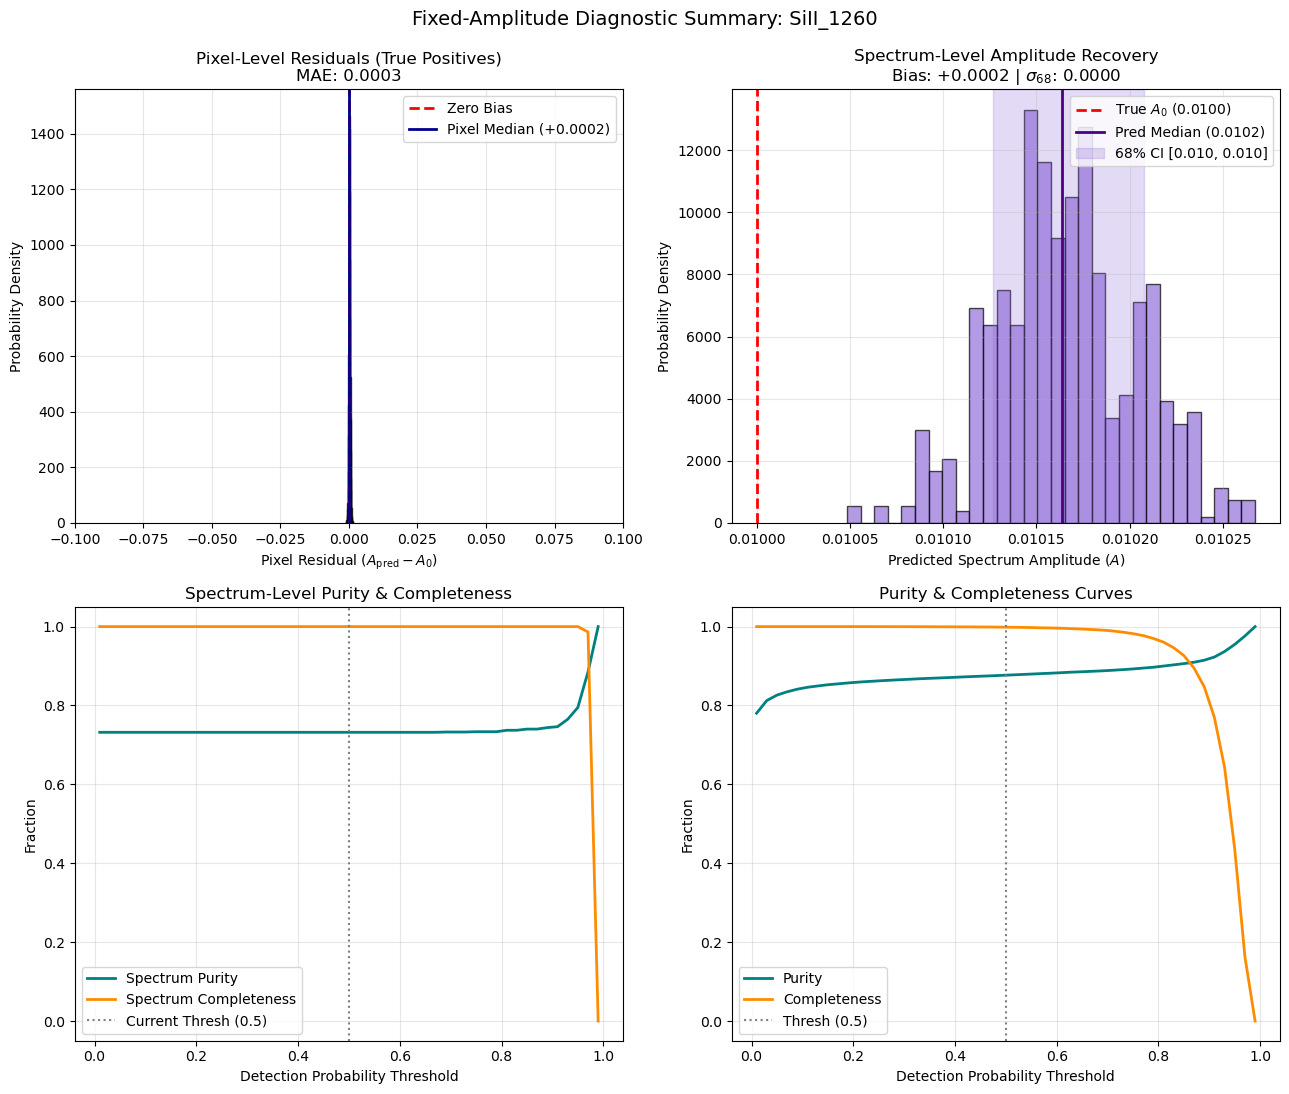

In [31]:
# 1. Load trained model weights directly onto GPU/CPU

# checkpoint_path = "SiII_1260-MgI_2853_unet-fixed_Amp.pt"
# checkpoint_path = "SiII_1260-MgI_2853-CIV_1550-unet-fixed_A.pt"
checkpoint_path = "../models/SiII_1260_low-A.pt"

model, _ = load_model_checkpoint(checkpoint_path,
                                 device=device, 
                                 model_class=SpectralDilatedUNet1D)

# 2. Run diagnostics directly
# evaluate_multimetal_unet(
evaluate_fixed_amplitude_unet(
    model=model,
    val_loader=val_loader,
    device=device,
    # metal_names = ["SiII_1260", 'MgI_2853', 'CIV_1550'],
    metal_names = ["SiII_1260"],
    prob_thresh=0.5
)

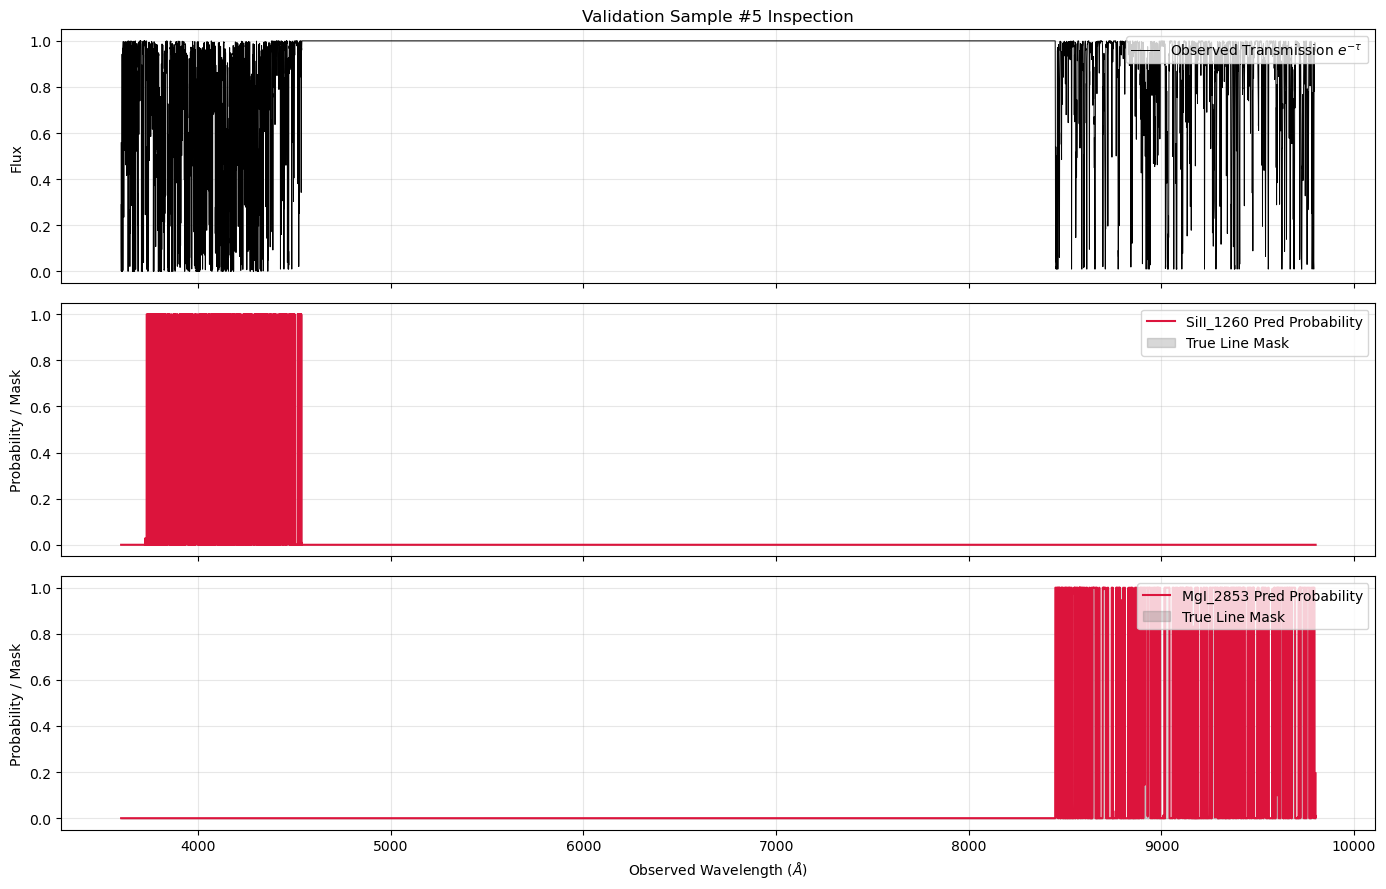

In [21]:
# 1. Load trained model weights directly onto GPU/CPU
# checkpoint_path = "SiII_1260-MgI_2853_unet-fixed_Amp.pt"

# model, _ = load_model_checkpoint(checkpoint_path,
#                                  device=device, 
#                                  model_class=SpectralDilatedUNet1D)


# 2. Inspect a specific 1D spectrum visually
plot_sample_spectrum_prediction(
    model=model,
    val_set=val_set,
    log_wave_grid=log_wave,
    device=device,
    sample_idx=5,
    # metal_names=['MgI_2853', 'CIV_1550'],
    # metal_names = ['SiII_1260'],
    metal_names = ["SiII_1260", 'MgI_2853'],
)